# Mixture Models for Semiconductor Defect Count

This notebook builds a simple hierarchical model for semiconductor defect counts using synthetic lot-wafer data.  
We start from a clear generative story, explore the simulated dataset, then compare a pooled Poisson regression, a Poisson mixed model, and a Negative Binomial model for predicting defect counts.

### Project layout

The notebook is organized as follows.

| Section | Content |
|--------|---------|
| §1 | Introduction and basic statistics for the synthetic lot-wafer dataset |
| §2 | Setup and configuration (libraries, plotting) |
| §3 | Exploratory data analysis (EDA) of humidity and defect counts by lot |
| §4 | Baseline pooled Poisson model (ignoring lot structure) |
| §5 | Poisson mixed model with lot-level effects |
| §6 | Negative Binomial model for overdispersion |
| §7 | Comparing models and predictions |
| §8 | Evaluation, theory/code summary, and possible extensions |

Each section starts with a short explanation of the objective, a brief description before each code block explaining *why* we run it, and a short interpretation after each result.

## 1. Introduction and basic statistics

The goal is to model wafer-level defect counts as a function of humidity while accounting for lot-to-lot variability.  
We construct a synthetic dataset where each wafer has a humidity value, a latent mean defect rate $\lambda_{\text{true}}$, and an observed defect count generated from a count distribution.

In other words, we define an explicit generative model:

1. Draw lot-level or wafer-level humidity values.
2. Map humidity into a true mean defect count $\lambda_{\text{true}}$ using a log-link relationship.
3. Add lot-level variation so that some lots are systematically better or worse than others.
4. For each wafer, simulate an observed count around $\lambda_{\text{true}}$.

This lets us check whether our statistical models can recover the known structure and make accurate predictions.

## 2. Setup and configuration

In this section we load core scientific Python libraries, set a fixed random seed for reproducibility, and configure plotting defaults.  
These imports and global options are used throughout the notebook for simulation, modeling, and visualization.

In [1]:
# ============================================================
# Library Imports
# ============================================================

# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.bayes_mixed_glm import PoissonBayesMixedGLM
from statsmodels.discrete.discrete_model import NegativeBinomial

# Set random seed for reproducibility
np.random.seed(42)

# Plotting style
sns.set_theme(style="whitegrid", context="talk")

### 2.1 Structure of synthetic data

The synthetic dataset contains **500 wafer-level observations** arranged in a hierarchical lot-wafer structure.

- There are **10 lots**, with **50 wafers per lot**.
- Each wafer is associated with:
  - `lot`: the lot identifier.
  - `humidity`: a continuous process covariate.
  - `lambda_true`: the latent expected defect count.
  - `defect_count`: the observed count outcome.
  - `lot_cat`: a categorical lot label used in the mixed model.

The true count structure is hierarchical:

- A global intercept and humidity slope define the population-average relationship.
- Each lot may also contribute extra variation, so lots can differ in their baseline count behavior.
- The observed counts are then generated from a stochastic count model centered on the latent mean.

So, structurally, the data have **three levels of interpretation**:

1. **Lot level**: shared process conditions and latent lot effects.
2. **Wafer level**: humidity and latent mean defect rate for each wafer.
3. **Count level**: realized defect counts generated from the underlying mean structure.

**Code: Create and inspect synthetic data structure**

The next code cell prints summary information for the training and test datasets and displays the first few rows of the training data.  
This checks that the simulated data have the intended dimensions, that the lot structure is correct, and that the response variable has a plausible scale before we start modeling.

In [2]:
# ============================================================
# Synthetic Data Generation - Overdispersed Counts
# ============================================================

# Parameters
n_lots = 10
wafers_per_lot = 50  # Larger sample for better mixed model estimation
n = n_lots * wafers_per_lot

# Generate lot and humidity structure
lot = np.repeat(np.arange(n_lots), wafers_per_lot)
humidity = np.random.normal(loc=0.5, scale=0.1, size=n)
humidity = np.clip(humidity, 0, 1)  # Keep in valid range

# True population-level fixed effects
beta_0 = 2.5  # Intercept on log scale
beta_1 = -3.0  # Humidity effect on log scale

# True lot-level random effects standard deviations
sigma_b0 = 0.6  # Random intercept SD
sigma_b1 = 0.8  # Random slope SD

# Generate lot-level random effects
b0_lot = np.random.normal(0, sigma_b0, size=n_lots)
b1_lot = np.random.normal(0, sigma_b1, size=n_lots)

# Compute log(lambda) - linear predictor
log_lambda = (
    beta_0 + 
    beta_1 * humidity + 
    b0_lot[lot] + 
    b1_lot[lot] * humidity
)

# Expected count
lambda_true = np.exp(log_lambda)

# OVERDISPERSED counts using Negative Binomial
# NB parameterization: larger alpha means MORE overdispersion
# alpha parameter (shape parameter of gamma mixing distribution)
alpha = 2.0  # Moderate overdispersion

# Generate negative binomial counts
# Using alternative parameterization: n (size) and p (probability)
# Relationship: mean = lambda, var = lambda + lambda^2/alpha
# So: n = alpha, p = alpha/(alpha + lambda)
n_param = alpha
p_param = alpha / (alpha + lambda_true)

# Generate overdispersed counts
defect_count = np.random.negative_binomial(n_param, p_param, size=n)

# Create training dataframe
df = pd.DataFrame({
    'lot': lot,
    'humidity': humidity,
    'lambda_true': lambda_true,
    'defect_count': defect_count
})

# Add categorical lot for formulas
df['lot_cat'] = df['lot'].astype('category')


# ============================================================
# Generate Test Data (New Lots)
# ============================================================

# Generate test data with SAME structure but NEW lot realizations
n_test = n_lots * wafers_per_lot

lot_test = np.repeat(np.arange(n_lots), wafers_per_lot)
humidity_test = np.random.normal(loc=0.5, scale=0.1, size=n_test)
humidity_test = np.clip(humidity_test, 0, 1)

# Generate NEW lot-level random effects for test data
b0_lot_test = np.random.normal(0, sigma_b0, size=n_lots)
b1_lot_test = np.random.normal(0, sigma_b1, size=n_lots)

# Compute log(lambda) for test
log_lambda_test = (
    beta_0 + 
    beta_1 * humidity_test + 
    b0_lot_test[lot_test] + 
    b1_lot_test[lot_test] * humidity_test
)

lambda_true_test = np.exp(log_lambda_test)

# Generate test counts (overdispersed)
p_param_test = alpha / (alpha + lambda_true_test)
defect_count_test = np.random.negative_binomial(n_param, p_param_test, size=n_test)

# Create test dataframe
df_test = pd.DataFrame({
    'lot': lot_test,
    'humidity': humidity_test,
    'lambda_true': lambda_true_test,
    'defect_count': defect_count_test
})

df_test['lot_cat'] = df_test['lot'].astype('category')


# ============================================================
# Display Basic Statistics
# ============================================================

print("=" * 60)
print("TRAINING DATA SUMMARY")
print("=" * 60)
print(f"Number of observations: {len(df)}")
print(f"Number of lots: {n_lots}")
print(f"Wafers per lot: {wafers_per_lot}")
print(f"\nDefect count statistics:")
print(f"  Mean: {df['defect_count'].mean():.2f}")
print(f"  Variance: {df['defect_count'].var():.2f}")
print(f"  Var/Mean ratio: {df['defect_count'].var() / df['defect_count'].mean():.2f}")
print(f"  (Ratio > 1 indicates overdispersion)")

print("\n" + "=" * 60)
print("TEST DATA SUMMARY")
print("=" * 60)
print(f"Number of observations: {len(df_test)}")
print(f"\nDefect count statistics:")
print(f"  Mean: {df_test['defect_count'].mean():.2f}")
print(f"  Variance: {df_test['defect_count'].var():.2f}")
print(f"  Var/Mean ratio: {df_test['defect_count'].var() / df_test['defect_count'].mean():.2f}")

# Show first few rows
print("\n" + "=" * 60)
print("FIRST FEW ROWS OF TRAINING DATA")
print("\n" + "=" * 60)
display(df.head(10))

TRAINING DATA SUMMARY
Number of observations: 500
Number of lots: 10
Wafers per lot: 50

Defect count statistics:
  Mean: 3.14
  Variance: 16.32
  Var/Mean ratio: 5.20
  (Ratio > 1 indicates overdispersion)

TEST DATA SUMMARY
Number of observations: 500

Defect count statistics:
  Mean: 3.23
  Variance: 11.25
  Var/Mean ratio: 3.49

FIRST FEW ROWS OF TRAINING DATA



,lot,humidity,lambda_true,defect_count,lot_cat
0,0,0.549671,4.598004,0,0
1,0,0.486174,5.486974,5,0
2,0,0.564769,4.408773,1,0
3,0,0.652303,3.455383,1,0
4,0,0.476585,5.635405,4,0
5,0,0.476586,5.635379,9,0
6,0,0.657921,3.401764,2,0
7,0,0.576743,4.264238,3,0
8,0,0.453053,6.016910,4,0
9,0,0.554256,4.539697,11,0


**Result and Interpretation**

We see that the dataset contains the expected number of observations and that wafers are nested within lots as intended.  
The first rows also confirm that each observation has both a latent mean count `lambda_true` and an observed defect count `defect_count`, which is exactly the structure required for count regression.

The summary statistics are already informative.  
In particular, the variance is substantially larger than the mean, so the data are overdispersed relative to a simple Poisson model.  
This is an important early signal that a richer model, such as a mixed model or a Negative Binomial model, may be needed later.

**Code**

Create data form blup comparison

In [3]:
# ============================================================
# Generate Test Data (New Wafers in Existing Lots)
#    → df_test_new for BLUP comparison
# ============================================================

# Number of new wafers per existing lot
wafers_per_lot_test_new = 50
n_test_new = n_lots * wafers_per_lot_test_new

# Same lot labels as training
lot_test_new = np.repeat(np.arange(n_lots), wafers_per_lot_test_new)
lot_test_new_cat = pd.Categorical(lot_test_new, categories=np.arange(n_lots))

# New humidity values for these wafers
humidity_test_new = np.random.normal(loc=0.5, scale=0.1, size=n_test_new)
humidity_test_new = np.clip(humidity_test_new, 0, 1)

# Use the SAME lot-level random effects as training (b0_lot, b1_lot)
log_lambda_test_new = (
    beta_0
    + beta_1 * humidity_test_new
    + b0_lot[lot_test_new]
    + b1_lot[lot_test_new] * humidity_test_new
)
lambda_true_test_new = np.exp(log_lambda_test_new)

# Overdispersed counts via same NB mechanism
p_param_test_new = alpha / (alpha + lambda_true_test_new)
defect_count_test_new = np.random.negative_binomial(
    n_param, p_param_test_new, size=n_test_new
)

# Create new-in-lot test dataframe for BLUP evaluation
df_test_new = pd.DataFrame({
    "lot": lot_test_new,
    "lot_cat": lot_test_new_cat,
    "humidity": humidity_test_new,
    "lambda_true": lambda_true_test_new,
    "defect_count": defect_count_test_new,
})

print("\n" + "=" * 60)
print("NEW IN-LOT TEST DATA SUMMARY (df_test_new)")
print("=" * 60)
print(f"Number of observations: {len(df_test_new)}")
print(f"Number of lots: {n_lots}")
print(f"Wafers per lot (new): {wafers_per_lot_test_new}")
print(f"\nDefect count statistics:")
print(f"  Mean: {df_test_new['defect_count'].mean():.2f}")
print(f"  Variance: {df_test_new['defect_count'].var():.2f}")
print(f"  Var/Mean ratio: {df_test_new['defect_count'].var() / df_test_new['defect_count'].mean():.2f}")


NEW IN-LOT TEST DATA SUMMARY (df_test_new)
Number of observations: 500
Number of lots: 10
Wafers per lot (new): 50

Defect count statistics:
  Mean: 2.99
  Variance: 14.51
  Var/Mean ratio: 4.86


## 3. Exploratory data analysis (EDA)

Before fitting formal models, it is useful to understand the empirical structure of the response variable.  
For count data, the main questions are whether the counts are skewed, whether humidity appears related to the mean count, whether lot-level variation is visible, and whether zero counts occur often enough to matter.

**Code: Explore the defect-count distribution**

The next code cell summarizes the marginal distribution of defect counts and humidity and visualizes both variables.  
This gives a first empirical picture of the response before any model assumptions are imposed.

EDA: POISSON COUNT DATA

Defect count statistics:
  Mean: 3.14
  Variance: 16.32
  Var/Mean ratio: 5.20
  Min: 0
  Max: 26


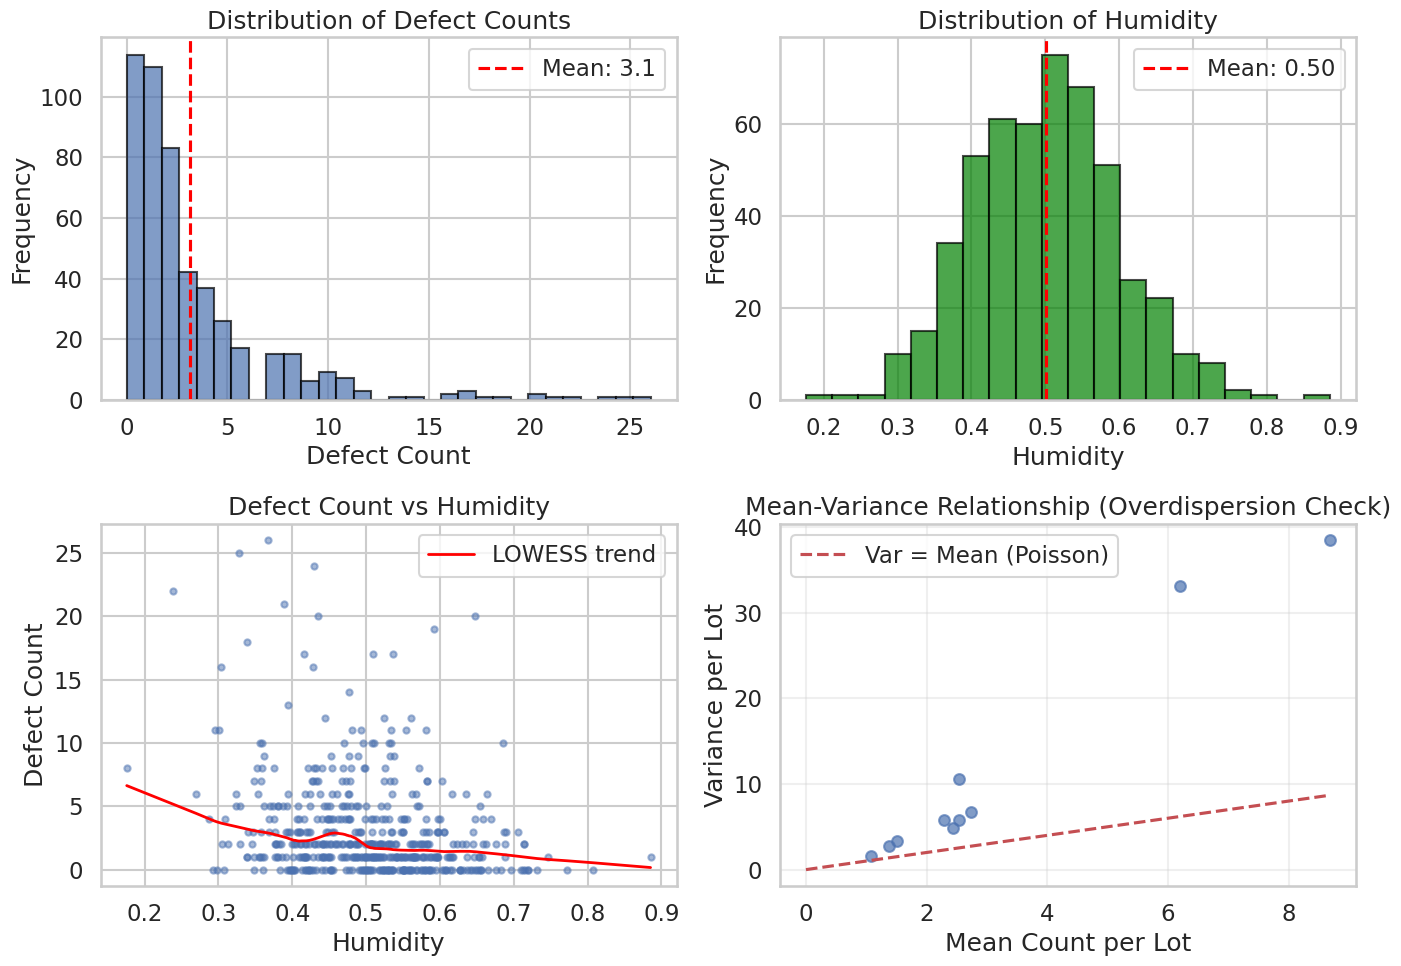

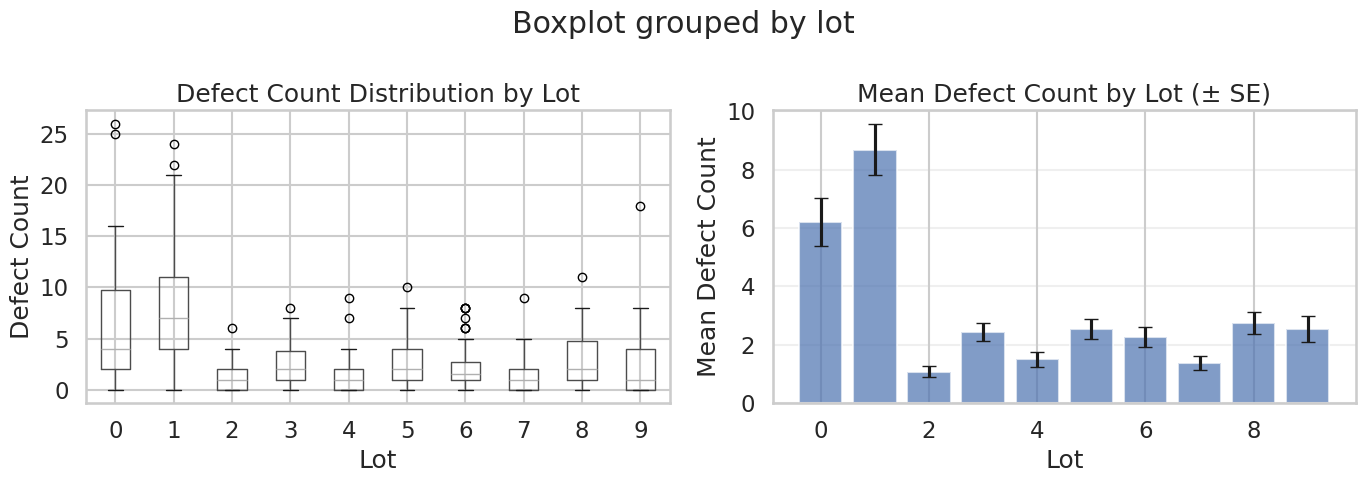


ZERO COUNT ANALYSIS
Number of wafers with zero defects: 114
Percentage with zero defects: 22.8%


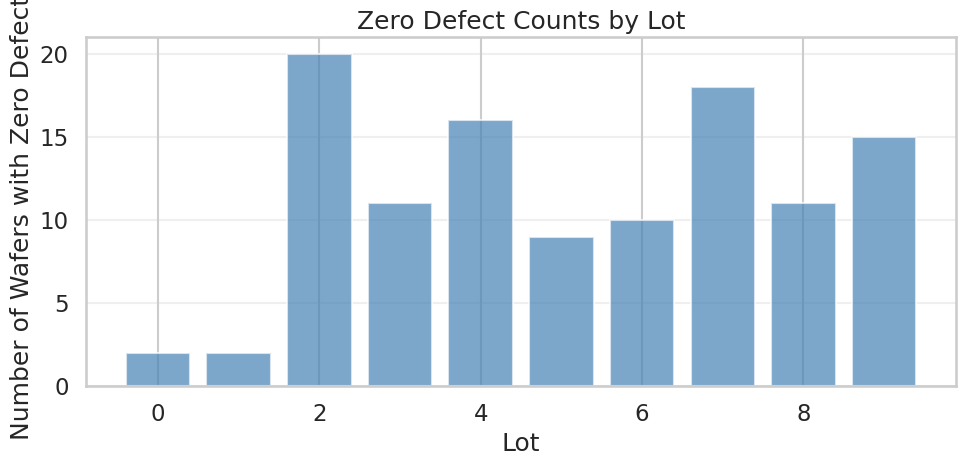


END OF EDA


In [4]:
# ============================================================
# 3. Exploratory Data Analysis (EDA)
# ============================================================

print("=" * 60)
print("EDA: POISSON COUNT DATA")
print("=" * 60)

# ---------------------------------------------
# Overall defect count distribution
# ---------------------------------------------
print(f"\nDefect count statistics:")
print(f"  Mean: {df['defect_count'].mean():.2f}")
print(f"  Variance: {df['defect_count'].var():.2f}")
print(f"  Var/Mean ratio: {df['defect_count'].var() / df['defect_count'].mean():.2f}")
print(f"  Min: {df['defect_count'].min()}")
print(f"  Max: {df['defect_count'].max()}")

# Create visualization grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Defect count histogram
axes[0, 0].hist(df['defect_count'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['defect_count'].mean(), color='red', 
                   linestyle='--', label=f"Mean: {df['defect_count'].mean():.1f}")
axes[0, 0].set_xlabel('Defect Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Defect Counts')
axes[0, 0].legend()

# 2. Humidity distribution
axes[0, 1].hist(df['humidity'], bins=20, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].axvline(df['humidity'].mean(), color='red', 
                   linestyle='--', label=f"Mean: {df['humidity'].mean():.2f}")
axes[0, 1].set_xlabel('Humidity')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Humidity')
axes[0, 1].legend()

# 3. Scatter plot: defect count vs humidity
axes[1, 0].scatter(df['humidity'], df['defect_count'], alpha=0.5, s=20)
axes[1, 0].set_xlabel('Humidity')
axes[1, 0].set_ylabel('Defect Count')
axes[1, 0].set_title('Defect Count vs Humidity')

# Add a lowess smoother to show trend
from statsmodels.nonparametric.smoothers_lowess import lowess
lowess_result = lowess(df['defect_count'], df['humidity'], frac=0.3)
axes[1, 0].plot(lowess_result[:, 0], lowess_result[:, 1], 
               color='red', linewidth=2, label='LOWESS trend')
axes[1, 0].legend()

# 4. Mean vs Variance by lot (overdispersion check)
lot_stats = df.groupby('lot')['defect_count'].agg(['mean', 'var']).reset_index()
axes[1, 1].scatter(lot_stats['mean'], lot_stats['var'], s=60, alpha=0.7)
axes[1, 1].plot([0, lot_stats['mean'].max()], [0, lot_stats['mean'].max()], 
               'r--', label='Var = Mean (Poisson)')
axes[1, 1].set_xlabel('Mean Count per Lot')
axes[1, 1].set_ylabel('Variance per Lot')
axes[1, 1].set_title('Mean-Variance Relationship (Overdispersion Check)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# # ---------------------------------------------
# # Lot-level analysis
# # ---------------------------------------------
# print("\n" + "=" * 60)
# print("LOT-LEVEL STATISTICS")
# print("=" * 60)

# lot_summary = df.groupby('lot').agg({
#     'humidity': ['mean', 'std'],
#     'defect_count': ['mean', 'std', 'min', 'max', 'count']
# }).round(2)

# lot_summary.columns = ['_'.join(col).strip() for col in lot_summary.columns.values]
# print(lot_summary)

# Visualize lot-level variation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot of defect counts by lot
df.boxplot(column='defect_count', by='lot', ax=axes[0])
axes[0].set_title('Defect Count Distribution by Lot')
axes[0].set_xlabel('Lot')
axes[0].set_ylabel('Defect Count')
plt.sca(axes[0])
plt.xticks(rotation=0)

# Mean defect count by lot with error bars
lot_means = df.groupby('lot')['defect_count'].mean()
lot_sems = df.groupby('lot')['defect_count'].sem()

axes[1].bar(lot_means.index, lot_means.values, 
           yerr=lot_sems.values, capsize=5, alpha=0.7)
axes[1].set_xlabel('Lot')
axes[1].set_ylabel('Mean Defect Count')
axes[1].set_title('Mean Defect Count by Lot (± SE)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ---------------------------------------------
# Zero counts analysis
# ---------------------------------------------
print("\n" + "=" * 60)
print("ZERO COUNT ANALYSIS")
print("=" * 60)

zero_count = (df['defect_count'] == 0).sum()
zero_pct = 100 * zero_count / len(df)

print(f"Number of wafers with zero defects: {zero_count}")
print(f"Percentage with zero defects: {zero_pct:.1f}%")

# Visualize zero distribution by lot
zero_by_lot = df.groupby('lot')['defect_count'].apply(lambda x: (x == 0).sum())
plt.figure(figsize=(10, 5))
plt.bar(zero_by_lot.index, zero_by_lot.values, alpha=0.7, color='steelblue')
plt.xlabel('Lot')
plt.ylabel('Number of Wafers with Zero Defects')
plt.title('Zero Defect Counts by Lot')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("END OF EDA")
print("=" * 60)

**Result and interpretation**

The defect-count distribution should be read as a direct check on the plausibility of count-data models.  
If the histogram is right-skewed and concentrated on small nonnegative integers, then the data have the expected broad shape for Poisson-type modeling.

The humidity distribution is also important because it defines the range over which the regression models will be asked to learn a signal.  
If humidity values cover a reasonable range without being too concentrated at a single point, then the regression slope is identifiable in a meaningful way.


## 4. Baseline pooled Poisson model

We now fit the simplest count regression in the notebook: a pooled Poisson generalized linear model that ignores lot-level dependence.  
This gives a clean baseline for the humidity effect and provides a reference point for more flexible models later.

The model is

$\log \lambda_i = \beta_0 + \beta_1 \,\text{humidity}_i$

with

$Y_i \mid X_i \sim \text{Poisson}(\lambda_i)$.

**Code: Fit the pooled Poisson regression**

The next code cell fits a Poisson GLM with `defect_count` as the response and `humidity` as the predictor.  
It then prints the model summary and extracts coefficient-based interpretations.

In [5]:
# ============================================================
# 4. Baseline Pooled Poisson Model (No Lot Structure)
# ============================================================

print("\n" + "=" * 60)
print("BASELINE POOLED POISSON REGRESSION")
print("=" * 60)
print("\nObjective: Fit a simple Poisson GLM ignoring lot-level structure")
print("Model: log(λ) = β₀ + β₁·humidity")
print("Assumption: All wafers are independent, no lot effects\n")

# ---------------------------------------------
# Fit pooled Poisson model
# ---------------------------------------------
pooled_poisson = smf.glm(
    'defect_count ~ humidity',
    data=df,
    family=sm.families.Poisson()
).fit()

print("=" * 60)
print("POOLED POISSON MODEL SUMMARY")
print("=" * 60)
print(pooled_poisson.summary())

# ---------------------------------------------
# Extract and interpret coefficients
# ---------------------------------------------
print("\n" + "=" * 60)
print("COEFFICIENT INTERPRETATION")
print("=" * 60)

beta0_hat = pooled_poisson.params['Intercept']
beta1_hat = pooled_poisson.params['humidity']

print(f"\nIntercept (β₀): {beta0_hat:.4f}")
print(f"  → log(λ) when humidity = 0: {beta0_hat:.4f}")
print(f"  → λ when humidity = 0: {np.exp(beta0_hat):.4f} defects")

print(f"\nHumidity coefficient (β₁): {beta1_hat:.4f}")
print(f"  → Rate ratio per unit humidity increase: {np.exp(beta1_hat):.4f}")
if beta1_hat > 0:
    print(f"  → Each +1 humidity increases defect rate by {100*(np.exp(beta1_hat)-1):.1f}%")
else:
    print(f"  → Each +1 humidity decreases defect rate by {100*(1-np.exp(beta1_hat)):.1f}%")




BASELINE POOLED POISSON REGRESSION

Objective: Fit a simple Poisson GLM ignoring lot-level structure
Model: log(λ) = β₀ + β₁·humidity
Assumption: All wafers are independent, no lot effects

POOLED POISSON MODEL SUMMARY
                 Generalized Linear Model Regression Results                  
Dep. Variable:           defect_count   No. Observations:                  500
Model:                            GLM   Df Residuals:                      498
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1500.1
Date:                Mon, 11 May 2026   Deviance:                       1867.0
Time:                        10:44:05   Pearson chi2:                 2.33e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.2779
Covariance Type:            nonrobust                                

### Result and interpretation

The pooled Poisson model gives the first formal estimate of how humidity shifts the expected defect count.  
Because the model uses a log link, the slope coefficient describes a multiplicative effect on the expected count rather than an additive one.

If the humidity coefficient is negative, then higher humidity is associated with a lower expected count.  
That provides a clear directional interpretation, but the result should still be treated as a baseline rather than a final answer, because the model assumes equidispersion and ignores lot-level structure.

**Code: Generate example predictions at selected humidity values**

The next code cell evaluates the fitted model at a few representative humidity values.  
This translates the regression coefficients into predicted counts that are easier to interpret in process terms.

In [6]:
# Example predictions at different humidity levels
print("\n" + "-" * 60)
print("EXAMPLE PREDICTIONS")
print("-" * 60)
humidity_examples = [0.3, 0.5, 0.7]
for h in humidity_examples:
    lambda_pred = np.exp(beta0_hat + beta1_hat * h)
    print(f"Humidity = {h:.1f} → Predicted defect count: {lambda_pred:.2f}")


------------------------------------------------------------
EXAMPLE PREDICTIONS
------------------------------------------------------------
Humidity = 0.3 → Predicted defect count: 5.82
Humidity = 0.5 → Predicted defect count: 2.98
Humidity = 0.7 → Predicted defect count: 1.53


### Result and interpretation

These predicted values make the fitted model more concrete.  
Instead of speaking only in terms of coefficients, we can now say what defect count the model expects at humidity levels such as 0.3, 0.5, or 0.7.

This is often the most intuitive way to communicate the model.  
It connects the statistical fit directly to expected wafer behavior under different operating conditions.

**Code: Visualize the pooled Poisson fit and prediction spread**

The next code cell overlays the fitted Poisson mean on the observed data and adds a Poisson-style spread band around the fitted curve.  
This allows us to compare model-implied variability with the actual scatter in the observations.


POOLED POISSON FIT WITH PREDICTION INTERVAL


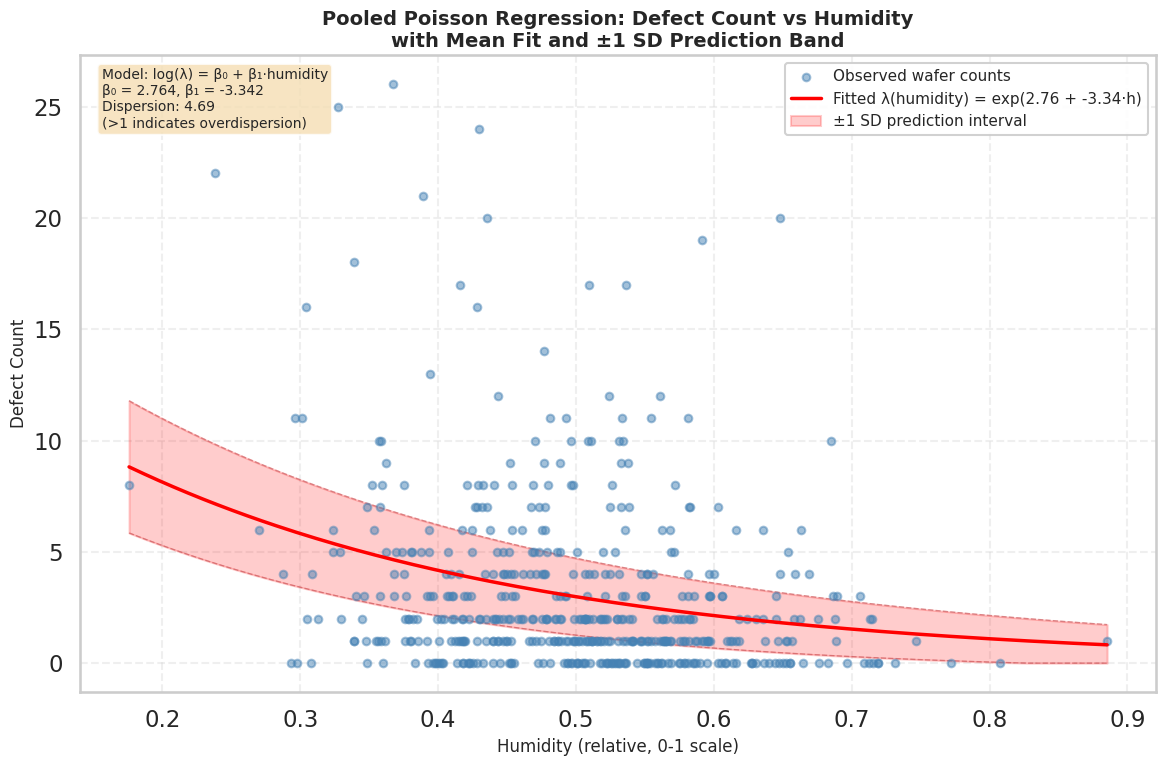


Interpretation:
  • The red curve shows E[Count|humidity] = λ(humidity)
  • For Poisson: Var(Count) = λ, so SD = √λ
  • Shaded band: λ ± √λ (covers ~68% of observations if well-fitted)
  • Band width increases with λ (heteroscedasticity)
  • Negative β₁ = -3.342 → defects ↓ as humidity ↑
  • Rate multiplier per +0.1 humidity: 0.716


In [7]:
# ============================================================
# Enhanced Pooled Poisson Visualization with Prediction Band
# ============================================================

print("\n" + "=" * 60)
print("POOLED POISSON FIT WITH PREDICTION INTERVAL")
print("=" * 60)

# Create humidity grid for smooth predictions
humidity_grid = np.linspace(df['humidity'].min(), df['humidity'].max(), 200)

# Predicted mean (λ)
lambda_pred = np.exp(beta0_hat + beta1_hat * humidity_grid)

# For Poisson: Var(Y) = λ, so SD = sqrt(λ)
# ±1 SD prediction band
sd_pred = np.sqrt(lambda_pred)
lower_band = lambda_pred - sd_pred
upper_band = lambda_pred + sd_pred

# Ensure non-negative lower bound (counts can't be negative)
lower_band = np.maximum(lower_band, 0)

# Create the plot
plt.figure(figsize=(12, 8))

# Scatter plot of observed data
plt.scatter(df['humidity'], df['defect_count'], 
           alpha=0.5, s=30, color='steelblue', 
           label='Observed wafer counts', zorder=3)

# Fitted mean λ(humidity)
plt.plot(humidity_grid, lambda_pred, 
        color='red', linewidth=2.5, 
        label=f'Fitted λ(humidity) = exp({beta0_hat:.2f} + {beta1_hat:.2f}·h)', 
        zorder=4)

# ±1 SD prediction band
plt.fill_between(humidity_grid, lower_band, upper_band,
                color='red', alpha=0.2, 
                label='±1 SD prediction interval', 
                zorder=2)

# Plot the band edges as dashed lines for clarity
plt.plot(humidity_grid, upper_band, 'r--', linewidth=1, alpha=0.6, zorder=2)
plt.plot(humidity_grid, lower_band, 'r--', linewidth=1, alpha=0.6, zorder=2)

# Formatting
plt.xlabel('Humidity (relative, 0-1 scale)', fontsize=12)
plt.ylabel('Defect Count', fontsize=12)
plt.title('Pooled Poisson Regression: Defect Count vs Humidity\nwith Mean Fit and ±1 SD Prediction Band', 
         fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--')

# Add interpretation text box
textstr = '\n'.join([
    f'Model: log(λ) = β₀ + β₁·humidity',
    f'β₀ = {beta0_hat:.3f}, β₁ = {beta1_hat:.3f}',
    f'Dispersion: {pooled_poisson.pearson_chi2 / pooled_poisson.df_resid:.2f}',
    f'(>1 indicates overdispersion)'
])
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(0.02, 0.98, textstr, transform=plt.gca().transAxes, 
        fontsize=10, verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

# Print interpretation
print("\nInterpretation:")
print(f"  • The red curve shows E[Count|humidity] = λ(humidity)")
print(f"  • For Poisson: Var(Count) = λ, so SD = √λ")
print(f"  • Shaded band: λ ± √λ (covers ~68% of observations if well-fitted)")
print(f"  • Band width increases with λ (heteroscedasticity)")
print(f"  • Negative β₁ = {beta1_hat:.3f} → defects ↓ as humidity ↑")
print(f"  • Rate multiplier per +0.1 humidity: {np.exp(0.1*beta1_hat):.3f}")

**Result and Interpretation**

A model can capture the mean trend reasonably well while still failing to capture the variance.  
If the observed points are substantially more dispersed than the Poisson band suggests, then the problem is not necessarily the sign of the humidity effect but the variance assumption of the model.

This distinction is important.  
The Poisson model may still teach us something about the mean structure, but it may be too optimistic about uncertainty and too rigid about the count variability.

**Code**


MODEL DIAGNOSTICS

Deviance: 1866.96
Pearson χ²: 2334.32
Dispersion parameter: 4.69
  (Should be ≈1 for well-fitted Poisson; >1 suggests overdispersion)

AIC: 3004.16
BIC: -1227.92
Log-likelihood: -1500.08


/home/python_user/coding/ds/.venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


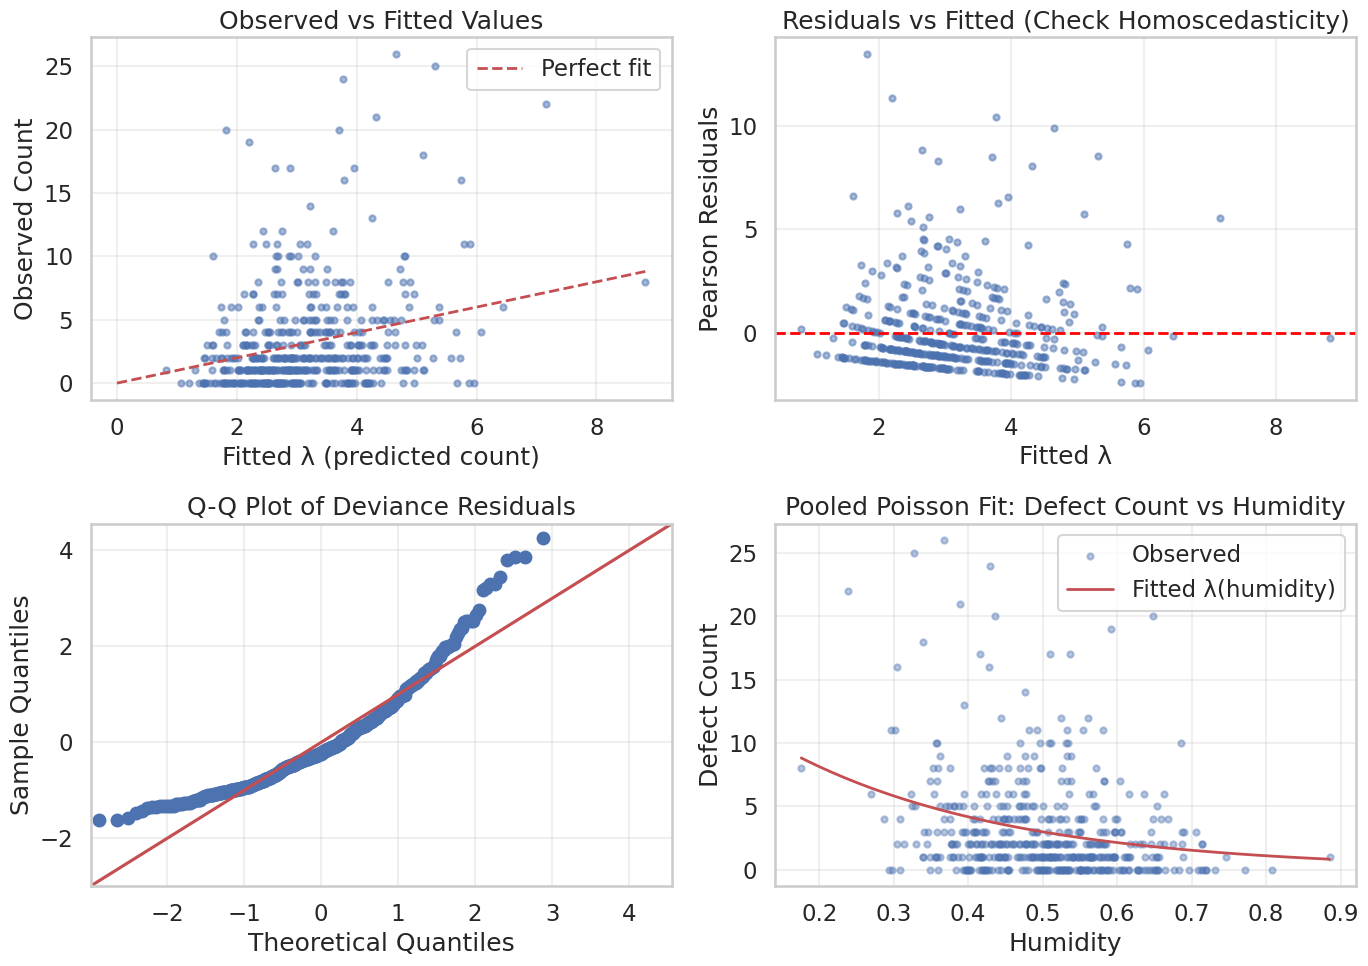

In [8]:

# ---------------------------------------------
# Model diagnostics
# ---------------------------------------------
print("\n" + "=" * 60)
print("MODEL DIAGNOSTICS")
print("=" * 60)

# Pearson residuals
df['pearson_resid'] = pooled_poisson.resid_pearson
df['deviance_resid'] = pooled_poisson.resid_deviance
df['fitted_lambda'] = pooled_poisson.fittedvalues

print(f"\nDeviance: {pooled_poisson.deviance:.2f}")
print(f"Pearson χ²: {pooled_poisson.pearson_chi2:.2f}")
print(f"Dispersion parameter: {pooled_poisson.pearson_chi2 / pooled_poisson.df_resid:.2f}")
print(f"  (Should be ≈1 for well-fitted Poisson; >1 suggests overdispersion)")

# AIC/BIC
print(f"\nAIC: {pooled_poisson.aic:.2f}")
print(f"BIC: {pooled_poisson.bic:.2f}")
print(f"Log-likelihood: {pooled_poisson.llf:.2f}")

# ---------------------------------------------
# Visualizations
# ---------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Observed vs Fitted
axes[0, 0].scatter(df['fitted_lambda'], df['defect_count'], alpha=0.5, s=20)
axes[0, 0].plot([0, df['fitted_lambda'].max()], [0, df['fitted_lambda'].max()], 
               'r--', linewidth=2, label='Perfect fit')
axes[0, 0].set_xlabel('Fitted λ (predicted count)')
axes[0, 0].set_ylabel('Observed Count')
axes[0, 0].set_title('Observed vs Fitted Values')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals vs Fitted
axes[0, 1].scatter(df['fitted_lambda'], df['pearson_resid'], alpha=0.5, s=20)
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Fitted λ')
axes[0, 1].set_ylabel('Pearson Residuals')
axes[0, 1].set_title('Residuals vs Fitted (Check Homoscedasticity)')
axes[0, 1].grid(True, alpha=0.3)

# 3. Q-Q plot of deviance residuals
sm.qqplot(df['deviance_resid'], line='45', ax=axes[1, 0], fit=True)
axes[1, 0].set_title('Q-Q Plot of Deviance Residuals')
axes[1, 0].grid(True, alpha=0.3)

# 4. Fitted regression line
humidity_grid = np.linspace(df['humidity'].min(), df['humidity'].max(), 100)
lambda_pred = np.exp(beta0_hat + beta1_hat * humidity_grid)

axes[1, 1].scatter(df['humidity'], df['defect_count'], alpha=0.4, s=20, label='Observed')
axes[1, 1].plot(humidity_grid, lambda_pred, 'r-', linewidth=2, label='Fitted λ(humidity)')
axes[1, 1].set_xlabel('Humidity')
axes[1, 1].set_ylabel('Defect Count')
axes[1, 1].set_title('Pooled Poisson Fit: Defect Count vs Humidity')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**Result and interpretation**

**Code**

<Figure size 1200x500 with 0 Axes>

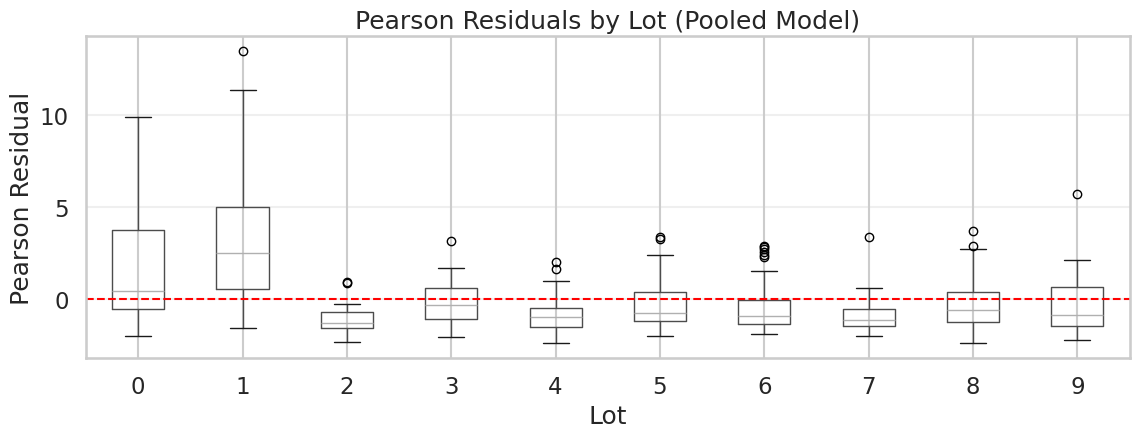


END OF POOLED MODEL ANALYSIS


In [9]:
# # ---------------------------------------------
# # Residuals by lot (preview of lot effects)
# # ---------------------------------------------
# print("\n" + "=" * 60)
# print("RESIDUALS BY LOT (Checking for Systematic Lot Effects)")
# print("=" * 60)

# lot_resid_summary = df.groupby('lot')['pearson_resid'].agg(['mean', 'std', 'count'])
# print(lot_resid_summary.round(3))

# print("\nInterpretation:")
# print("  • Mean residuals should be ≈0 if no lot effects")
# print("  • Systematic positive/negative means suggest lot-level variation")
# print("  • This motivates a mixed model with random lot effects\n")

# Boxplot of residuals by lot
plt.figure(figsize=(12, 5))
df.boxplot(column='pearson_resid', by='lot', figsize=(12, 5))
plt.suptitle('')
plt.title('Pearson Residuals by Lot (Pooled Model)')
plt.xlabel('Lot')
plt.ylabel('Pearson Residual')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("END OF POOLED MODEL ANALYSIS")
print("=" * 60)

**Result and interpretation**

## 5. Poisson mixed model with lot-level effects

The next step is to relax the assumption that all wafers are conditionally identical once humidity is known.  
A Poisson mixed model allows each lot to contribute its own latent effect, which helps absorb persistent lot-to-lot variation.

In hierarchical form, a simple version of the model is

$Y_{ij} \mid b_j \sim \text{Poisson}(\lambda_{ij})$

and

$\log \lambda_{ij} = \beta_0 + \beta_1 \,\text{humidity}_{ij} + b_j$,

where $b_j$ is a random effect for lot $j$.

**Code: Fit the Poisson mixed model**

The next code cell fits a Poisson mixed-effects model using lot-level random effects.  
The goal is to separate the global humidity trend from the extra variation associated with specific lots.

In [10]:
from statsmodels.genmod.bayes_mixed_glm import PoissonBayesMixedGLM

# Fixed effects: intercept and humidity
exog_fe = sm.add_constant(df[["humidity"]])

# Random effects: lot-specific intercept and slope
lots = df["lot"].astype("category")
n_lots = lots.cat.categories.size

Z_list = []
ident = []

for j, lot in enumerate(lots.cat.categories):
    mask = (lots == lot).values

    Zi = np.zeros((df.shape[0], 2))
    Zi[mask, 0] = 1.0
    Zi[mask, 1] = df.loc[mask, "humidity"].values
    Z_list.append(Zi)

    ident.extend([j, j])

exog_re = np.concatenate(Z_list, axis=1)
ident = np.array(ident, dtype=int)

poisson_glmm = PoissonBayesMixedGLM(
    endog=df["defect_count"].values,
    exog=exog_fe.values,
    exog_vc=exog_re,
    ident=ident,
)

poisson_glmm_result = poisson_glmm.fit_vb()
print(poisson_glmm_result.summary())

             Poisson Mixed GLM Results
      Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
----------------------------------------------------
FE_1     M     2.4344   0.0251                      
FE_2     M    -3.2210   0.0524                      
VC_1     V    -0.1724   0.4635 0.842   0.333   2.127
VC_2     V     0.0236   0.4451 1.024   0.420   2.494
VC_3     V    -0.2916   0.4758 0.747   0.288   1.935
VC_4     V    -1.2714   0.6379 0.280   0.078   1.004
VC_5     V    -0.6941   0.5262 0.500   0.174   1.431
VC_6     V    -1.2765   0.6393 0.279   0.078   1.002
VC_7     V    -1.2755   0.6390 0.279   0.078   1.002
VC_8     V    -0.6119   0.5146 0.542   0.194   1.518
VC_9     V    -1.1905   0.6179 0.304   0.088   1.046
VC_10    V    -1.2175   0.6244 0.296   0.085   1.032
Parameter types are mean structure (M) and variance
structure (V)
Variance parameters are modeled as log standard
deviations


**Result and Interpretation**

The mixed model should be interpreted as decomposing the count process into two pieces: a population-average humidity effect and a lot-specific deviation from that average.  
If the fitted random-effect variance is nontrivial, then the data contain meaningful clustering that the pooled Poisson model could not explain.

This is often a more realistic description of semiconductor data.  
Lots typically share process conditions, equipment states, or latent quality factors that are not fully captured by a single measured covariate.

**Code: Compute fitted values and residual diagnostics for the mixed model**

The next code cell reconstructs fitted means from the mixed model and evaluates residual behavior.  
This is done so that the mixed model can be judged not only by its parameter estimates but also by how well it matches the observed count process.

In [11]:
# ============================================================
# Extract fixed and random-effect constants from Poisson GLMM
# ============================================================

# Fixed effects (population-level intercept and humidity slope)
beta_fe = poisson_glmm_result.fe_mean
beta0_glmm = float(beta_fe[0])
beta1_glmm = float(beta_fe[1])

print("Fixed effects (population level):")
print(f"  Intercept (beta0_glmm): {beta0_glmm:.6f}")
print(f"  Humidity  (beta1_glmm): {beta1_glmm:.6f}")
print(f"  exp(beta0_glmm): {np.exp(beta0_glmm):.6f}")
print(f"  exp(beta1_glmm): {np.exp(beta1_glmm):.6f}")

# Random effects (lot-level intercept and slope posterior means)
lots = df["lot"].astype("category")
n_lots = lots.cat.categories.size

re_mean = poisson_glmm_result.vc_mean
re_mean = re_mean.reshape(n_lots, 2)

lot_effects_glmm = pd.DataFrame(
    re_mean,
    index=lots.cat.categories,
    columns=["b0_lot_intercept", "b1_lot_humidity"],
)

print("\nFirst few lot-level random effects:")
print(lot_effects_glmm.head().round(6))

Fixed effects (population level):
  Intercept (beta0_glmm): 2.434352
  Humidity  (beta1_glmm): -3.221028
  exp(beta0_glmm): 11.408420
  exp(beta1_glmm): 0.039914

First few lot-level random effects:
   b0_lot_intercept  b1_lot_humidity
0          0.905553        -0.067320
1          0.960898         0.701691
2         -0.620795        -0.372614
3          0.031601         0.025026
4         -0.317012        -0.189796


**Result and interpretation**

The key question is whether the mixed model reduces systematic structure in the residuals.  
If residuals become more centered and less patterned by lot, then the random effect is doing meaningful explanatory work.

This would support the idea that some of the apparent overdispersion in the pooled Poisson model was actually unmodeled clustering.  
In that case, the mixed model is improving the representation of the data-generating mechanism rather than merely adding complexity.

**Code**

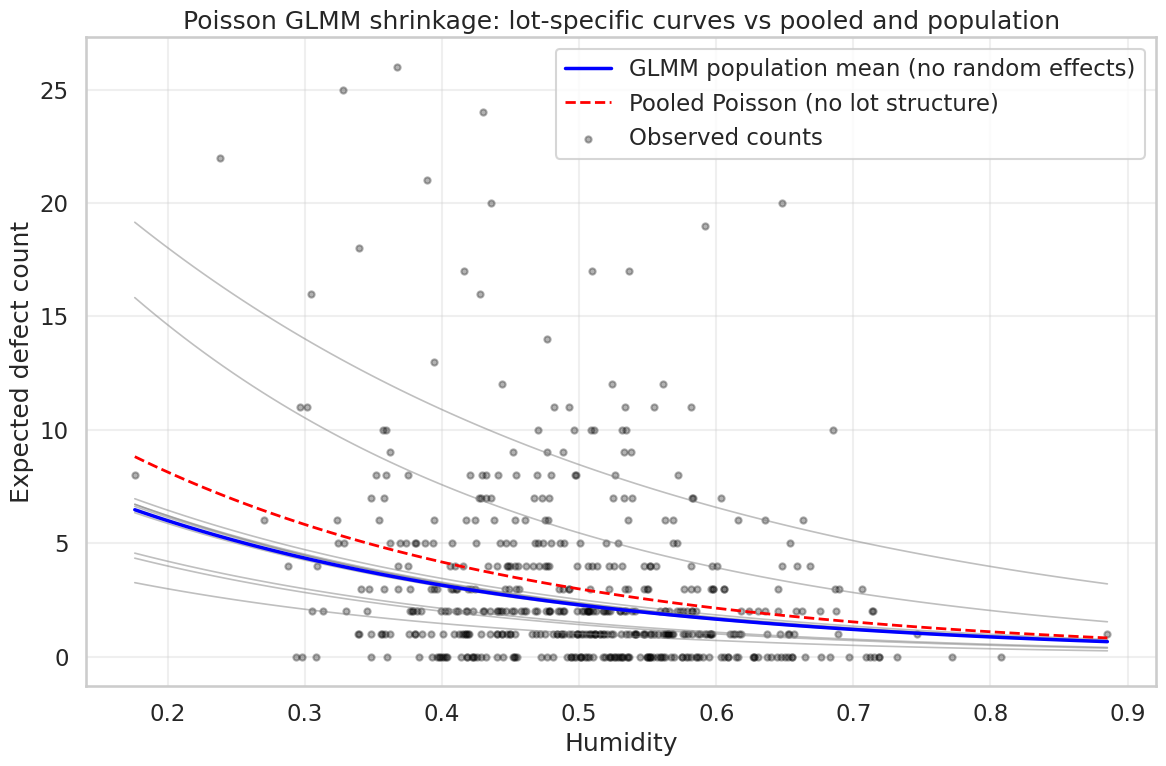

In [12]:
# ============================================================
# Shrinkage check: lot-specific curves vs pooled and population
# ============================================================

# --- Pooled Poisson fixed effects (from earlier glm fit) ---
beta0_pooled = pooled_poisson.params["Intercept"]
beta1_pooled = pooled_poisson.params["humidity"]

# --- GLMM fixed effects (population-level) ---
beta_fe_glmm = poisson_glmm_result.fe_mean
beta0_glmm = float(beta_fe_glmm[0])
beta1_glmm = float(beta_fe_glmm[1])

# --- Lot-level random effects from GLMM (intercept, slope) ---
lots = df["lot"].astype("category")
lot_levels = lots.cat.categories
n_lots = lot_levels.size

re_mean = poisson_glmm_result.vc_mean.reshape(n_lots, 2)
lot_effects_glmm = pd.DataFrame(
    re_mean,
    index=lot_levels,
    columns=["b0_lot_intercept", "b1_lot_humidity"],
)

# Humidity grid for smooth curves
h_grid = np.linspace(df["humidity"].min(), df["humidity"].max(), 100)

# --- Build curves ---

# Pooled Poisson curve
log_lambda_pooled = beta0_pooled + beta1_pooled * h_grid
lambda_pooled = np.exp(log_lambda_pooled)

# Population GLMM curve (no random effects)
log_lambda_glmm_pop = beta0_glmm + beta1_glmm * h_grid
lambda_glmm_pop = np.exp(log_lambda_glmm_pop)

# Lot-specific GLMM curves (with random intercept and slope)
lot_curves = {}
for lot in lot_levels:
    b0 = lot_effects_glmm.loc[lot, "b0_lot_intercept"]
    b1 = lot_effects_glmm.loc[lot, "b1_lot_humidity"]
    log_lambda_lot = beta0_glmm + beta1_glmm * h_grid + b0 + b1 * h_grid
    lot_curves[lot] = np.exp(log_lambda_lot)

# --- Plot ---

plt.figure(figsize=(12, 8))

# Plot lot-specific GLMM curves
for lot, lam_curve in lot_curves.items():
    plt.plot(
        h_grid,
        lam_curve,
        color="gray",
        alpha=0.5,
        linewidth=1.2,
    )

# Overlay population GLMM curve
plt.plot(
    h_grid,
    lambda_glmm_pop,
    color="blue",
    linewidth=2.5,
    label="GLMM population mean (no random effects)",
)

# Overlay pooled Poisson curve
plt.plot(
    h_grid,
    lambda_pooled,
    color="red",
    linestyle="--",
    linewidth=2.0,
    label="Pooled Poisson (no lot structure)",
)

# Add observed data as background scatter
plt.scatter(
    df["humidity"],
    df["defect_count"],
    s=20,
    alpha=0.3,
    color="black",
    label="Observed counts",
)

plt.xlabel("Humidity")
plt.ylabel("Expected defect count")
plt.title("Poisson GLMM shrinkage: lot-specific curves vs pooled and population")
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Result and Interpretation**

Each lot get its own logit curve

**Cdoe**

Eval model, start with pmfs

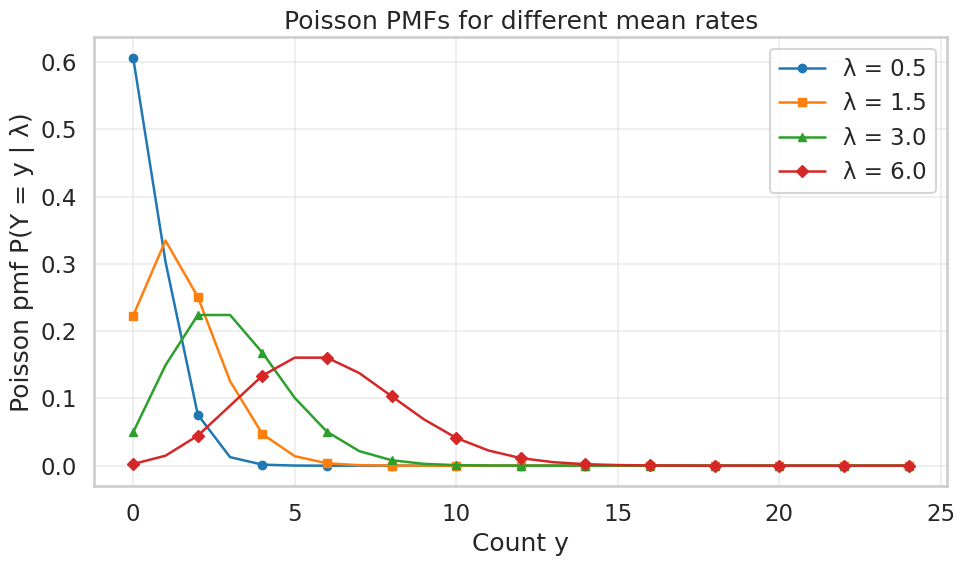

In [13]:
# ============================================================
# Poisson PMFs with distinct markers for each lambda
# ============================================================

from scipy.stats import poisson

lambda_values = [0.5, 1.5, 3.0, 6.0]
markers = ["o", "s", "^", "D"]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

x = np.arange(0, 25)

plt.figure(figsize=(10, 6))

for lam, marker, color in zip(lambda_values, markers, colors):
    pmf_vals = poisson.pmf(x, mu=lam)
    plt.plot(
        x,
        pmf_vals,
        marker=marker,
        markersize=6,
        markevery=2,
        linewidth=1.8,
        color=color,
        label=f"λ = {lam:.1f}",
    )

plt.xlabel("Count y")
plt.ylabel("Poisson pmf P(Y = y | λ)")
plt.title("Poisson PMFs for different mean rates")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Result and Interpretation**

**Code**

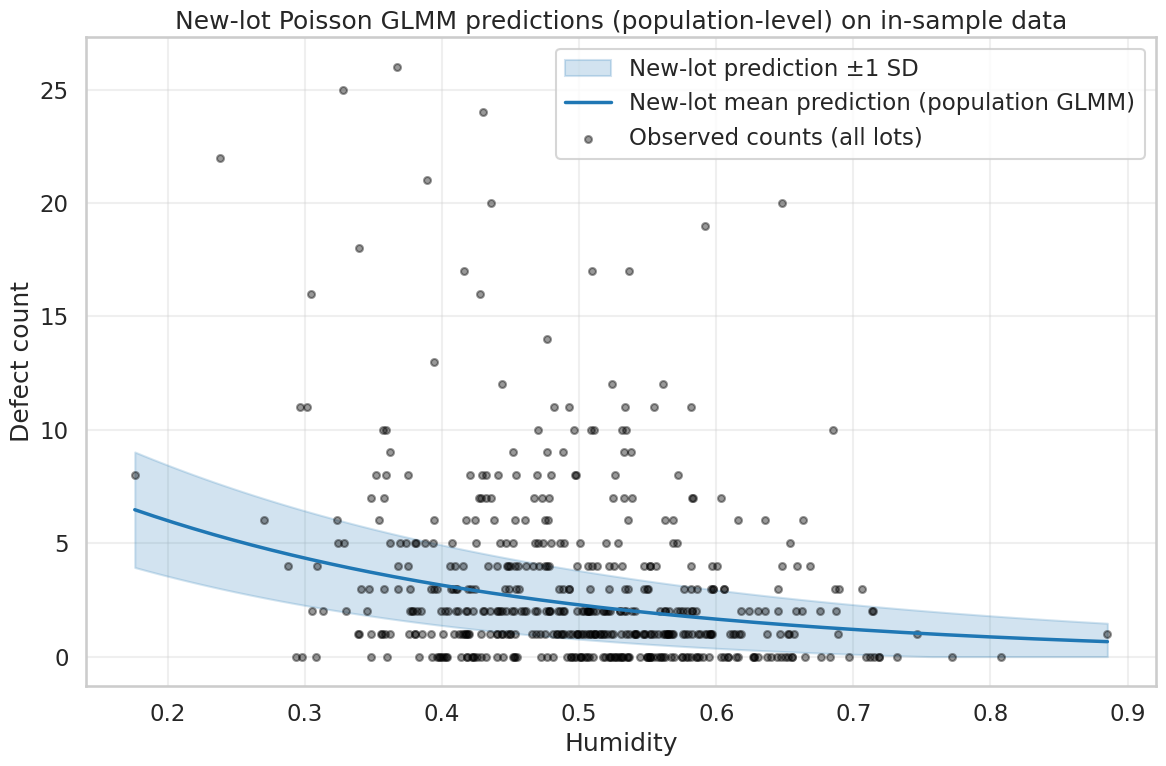

In [14]:
# ============================================================
# Population-level prediction (new-lot mode) on in-sample data
# ============================================================

# Fixed effects from GLMM (population-level)
beta_fe_glmm = poisson_glmm_result.fe_mean
beta0_glmm = float(beta_fe_glmm[0])
beta1_glmm = float(beta_fe_glmm[1])

# Humidity vector
h_in = df["humidity"].values

# New-lot (no random effects) prediction
log_lambda_newlot = beta0_glmm + beta1_glmm * h_in
lambda_newlot = np.exp(log_lambda_newlot)

# Poisson variance: Var = λ, so SD = sqrt(λ)
sd_newlot = np.sqrt(lambda_newlot)
lower_newlot = np.clip(lambda_newlot - sd_newlot, 0, None)
upper_newlot = lambda_newlot + sd_newlot

df["lambda_newlot"] = lambda_newlot
df["lambda_newlot_lower"] = lower_newlot
df["lambda_newlot_upper"] = upper_newlot

# Plot: smooth population curve + 1 SD band + observed data
h_grid = np.linspace(df["humidity"].min(), df["humidity"].max(), 200)
log_lambda_grid = beta0_glmm + beta1_glmm * h_grid
lambda_grid = np.exp(log_lambda_grid)
sd_grid = np.sqrt(lambda_grid)
lower_grid = np.clip(lambda_grid - sd_grid, 0, None)
upper_grid = lambda_grid + sd_grid

plt.figure(figsize=(12, 8))

plt.fill_between(
    h_grid,
    lower_grid,
    upper_grid,
    color="tab:blue",
    alpha=0.2,
    label="New-lot prediction ±1 SD",
)

plt.plot(
    h_grid,
    lambda_grid,
    color="tab:blue",
    linewidth=2.5,
    label="New-lot mean prediction (population GLMM)",
)

plt.scatter(
    df["humidity"],
    df["defect_count"],
    s=25,
    alpha=0.4,
    color="black",
    label="Observed counts (all lots)",
)

plt.xlabel("Humidity")
plt.ylabel("Defect count")
plt.title("New-lot Poisson GLMM predictions (population-level) on in-sample data")
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Result and Interpretation**

**Code**


POISSON GLMM RESIDUAL SUMMARY
Mean Pearson residual: 0.004
Std  Pearson residual: 1.558
Approx. dispersion (mean residual^2): 2.422


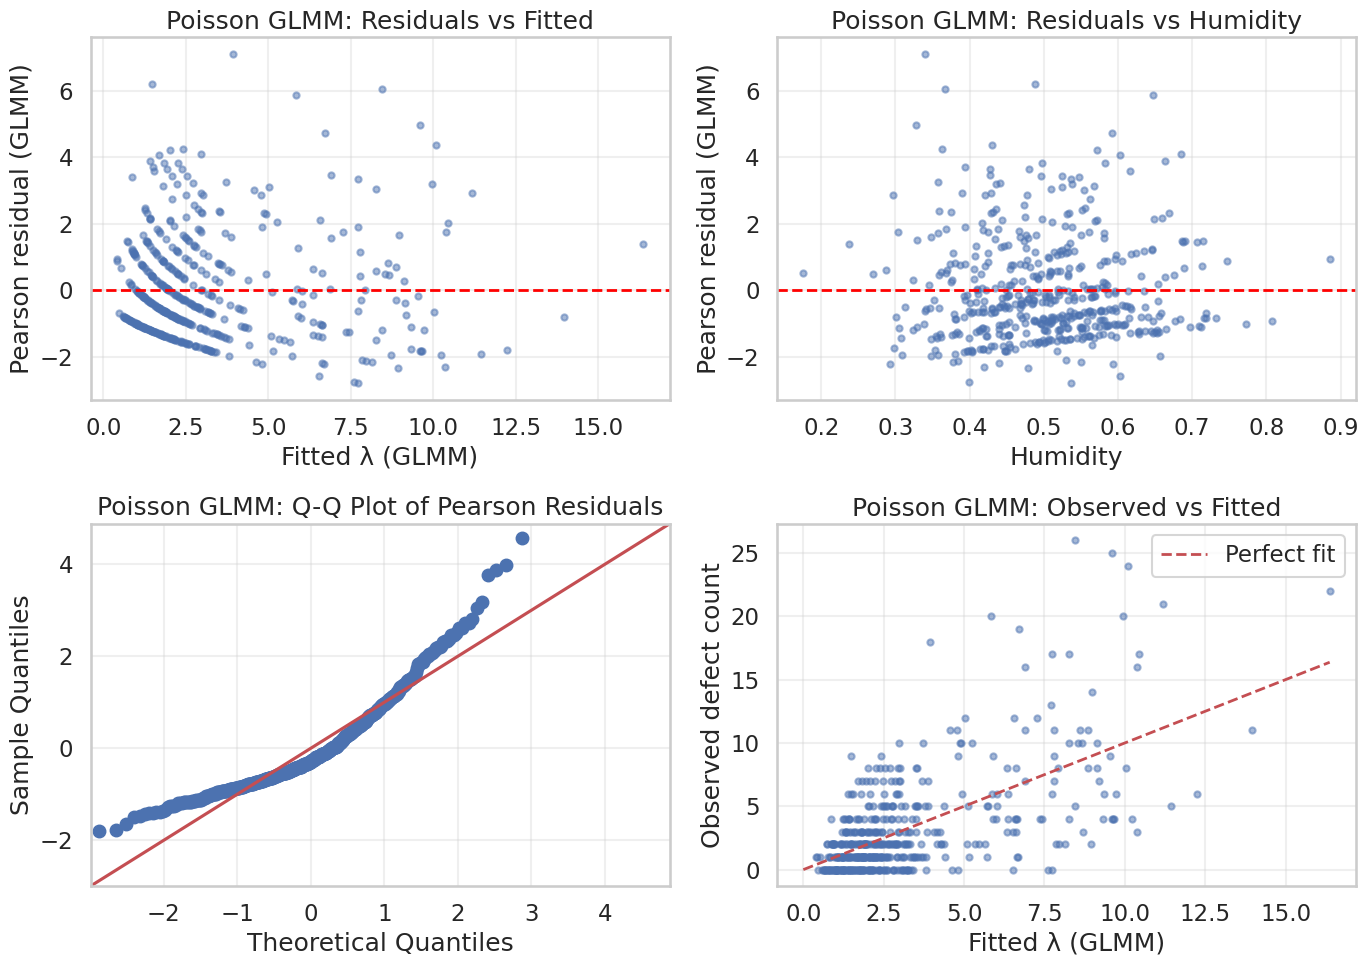


POISSON GLMM: RESIDUALS BY LOT
      mean    std  count
lot                     
0    0.013  2.049     50
1    0.020  2.037     50
2   -0.026  1.116     50
3    0.028  1.322     50
4   -0.029  1.302     50
5    0.030  1.451     50
6    0.009  1.578     50
7   -0.029  1.301     50
8    0.049  1.540     50
9   -0.020  1.735     50


<Figure size 1200x500 with 0 Axes>

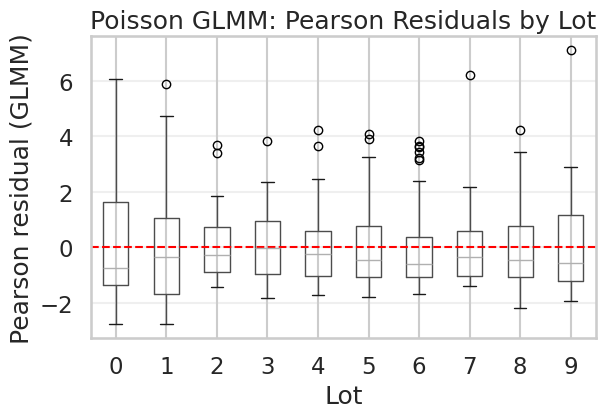


END OF POISSON GLMM RESIDUAL ANALYSIS


In [15]:
# ============================================================
# 6. Residual Diagnostics for Poisson GLMM
# ============================================================

# Fitted means from GLMM (using existing-lot random effects)
exog_fe_train = sm.add_constant(df[["humidity"]]).values
lots_train = df["lot"].astype("category")
lot_levels = lots_train.cat.categories
n_lots = lot_levels.size

Z_list = []
for lot in lot_levels:
    mask = (lots_train == lot).values
    Zi = np.zeros((df.shape[0], 2))
    Zi[mask, 0] = 1.0
    Zi[mask, 1] = df.loc[mask, "humidity"].values
    Z_list.append(Zi)
exog_re_train = np.concatenate(Z_list, axis=1)

linpred_glmm = (
    exog_fe_train @ poisson_glmm_result.fe_mean
    + exog_re_train @ poisson_glmm_result.vc_mean
)
lambda_glmm = np.exp(linpred_glmm)

df["lambda_glmm"] = lambda_glmm

# Pearson residuals for Poisson GLMM
y = df["defect_count"].values
pearson_resid_glmm = (y - lambda_glmm) / np.sqrt(lambda_glmm)
df["pearson_resid_glmm"] = pearson_resid_glmm

# ------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("POISSON GLMM RESIDUAL SUMMARY")
print("=" * 60)

print(f"Mean Pearson residual: {df['pearson_resid_glmm'].mean():.3f}")
print(f"Std  Pearson residual: {df['pearson_resid_glmm'].std(ddof=1):.3f}")

# Approximate dispersion: Var(residual) should be ~1 if Poisson variance is adequate
dispersion_glmm = np.mean(df["pearson_resid_glmm"]**2)
print(f"Approx. dispersion (mean residual^2): {dispersion_glmm:.3f}")

# ------------------------------------------------------------
# 4-panel residual plots
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs fitted
axes[0, 0].scatter(df["lambda_glmm"], df["pearson_resid_glmm"], alpha=0.5, s=20)
axes[0, 0].axhline(0, color="red", linestyle="--", linewidth=2)
axes[0, 0].set_xlabel("Fitted λ (GLMM)")
axes[0, 0].set_ylabel("Pearson residual (GLMM)")
axes[0, 0].set_title("Poisson GLMM: Residuals vs Fitted")
axes[0, 0].grid(alpha=0.3)

# 2. Residuals vs humidity
axes[0, 1].scatter(df["humidity"], df["pearson_resid_glmm"], alpha=0.5, s=20)
axes[0, 1].axhline(0, color="red", linestyle="--", linewidth=2)
axes[0, 1].set_xlabel("Humidity")
axes[0, 1].set_ylabel("Pearson residual (GLMM)")
axes[0, 1].set_title("Poisson GLMM: Residuals vs Humidity")
axes[0, 1].grid(alpha=0.3)

# 3. Q-Q plot of Pearson residuals
sm.qqplot(df["pearson_resid_glmm"], line="45", ax=axes[1, 0], fit=True)
axes[1, 0].set_title("Poisson GLMM: Q-Q Plot of Pearson Residuals")
axes[1, 0].grid(alpha=0.3)

# 4. Observed vs fitted counts
axes[1, 1].scatter(df["lambda_glmm"], df["defect_count"], alpha=0.5, s=20)
max_fit = df["lambda_glmm"].max()
axes[1, 1].plot([0, max_fit], [0, max_fit], "r--", linewidth=2, label="Perfect fit")
axes[1, 1].set_xlabel("Fitted λ (GLMM)")
axes[1, 1].set_ylabel("Observed defect count")
axes[1, 1].set_title("Poisson GLMM: Observed vs Fitted")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Residuals by lot
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("POISSON GLMM: RESIDUALS BY LOT")
print("=" * 60)

lot_resid_glmm = (
    df.groupby("lot")["pearson_resid_glmm"]
      .agg(["mean", "std", "count"])
      .round(3)
)
print(lot_resid_glmm)

plt.figure(figsize=(12, 5))
df.boxplot(column="pearson_resid_glmm", by="lot")
plt.suptitle("")
plt.title("Poisson GLMM: Pearson Residuals by Lot")
plt.xlabel("Lot")
plt.ylabel("Pearson residual (GLMM)")
plt.axhline(0, color="red", linestyle="--", linewidth=1.5)
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("END OF POISSON GLMM RESIDUAL ANALYSIS")
print("=" * 60)

## 6. Negative Binomial model for overdispersion

The Poisson model ties the variance to the mean, but the earlier summaries suggested that the data vary more than that.  
A Negative Binomial model is a natural extension because it retains the log-link mean structure while allowing the variance to grow faster than the mean.

A common specification is

$E(Y_i \mid X_i)=\mu_i$

and

$Var(Y_i \mid X_i)=\mu_i + \alpha \mu_i^2$,

where $\alpha > 0$ controls overdispersion.

**Code: Fit the Negative Binomial model**

The next code cell fits a Negative Binomial regression with the same fixed-effect structure as the pooled Poisson model.  
This isolates the effect of changing the variance model while keeping the mean structure comparable.

In [16]:
# ============================================================
# 7. Pooled Negative Binomial Model (No Lot Structure)
# ============================================================

from statsmodels.discrete.discrete_model import NegativeBinomial

# Design matrix: intercept + humidity (same as pooled Poisson)
X_nb = sm.add_constant(df[["humidity"]]).values
y_nb = df["defect_count"].values

nb_pooled = NegativeBinomial(endog=y_nb, exog=X_nb)
nb_pooled_result = nb_pooled.fit(method="newton", disp=0)

print("\n" + "=" * 60)
print("POOLED NEGATIVE BINOMIAL REGRESSION (NB2)")
print("=" * 60)
print(nb_pooled_result.summary())


POOLED NEGATIVE BINOMIAL REGRESSION (NB2)
                     NegativeBinomial Regression Results                      
Dep. Variable:                      y   No. Observations:                  500
Model:               NegativeBinomial   Df Residuals:                      498
Method:                           MLE   Df Model:                            1
Date:                Mon, 11 May 2026   Pseudo R-squ.:                 0.01646
Time:                        10:44:09   Log-Likelihood:                -1124.9
converged:                       True   LL-Null:                       -1143.7
Covariance Type:            nonrobust   LLR p-value:                 8.486e-10
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.7255      0.265     10.294      0.000       2.207       3.245
x1            -3.2618      0.527     -6.184      0.000      -4.296      -2.228
alpha    

**Results and Interpretation**

The Negative Binomial model addresses overdispersion directly.  
Instead of introducing explicit lot-level latent effects, it allows the count process itself to be more variable than the Poisson assumption permits.

If the fitted overdispersion parameter is clearly positive and the fit improves, then the data contain genuine extra-Poisson variation.  
That makes the NB model a natural competitor to the mixed Poisson model.

**Code: Examine fitted values and diagnostics for the Negative Binomial model**

The next code cell evaluates the fitted NB model through predictions and residual-based checks.  
This provides a direct comparison with the earlier Poisson-based fits.


NEGATIVE BINOMIAL PARAMETERS
Intercept (beta0_nb): 2.725548
Humidity  (beta1_nb): -3.261814
exp(beta0_nb): 15.264778
exp(beta1_nb): 0.038319
Overdispersion alpha: 0.967936


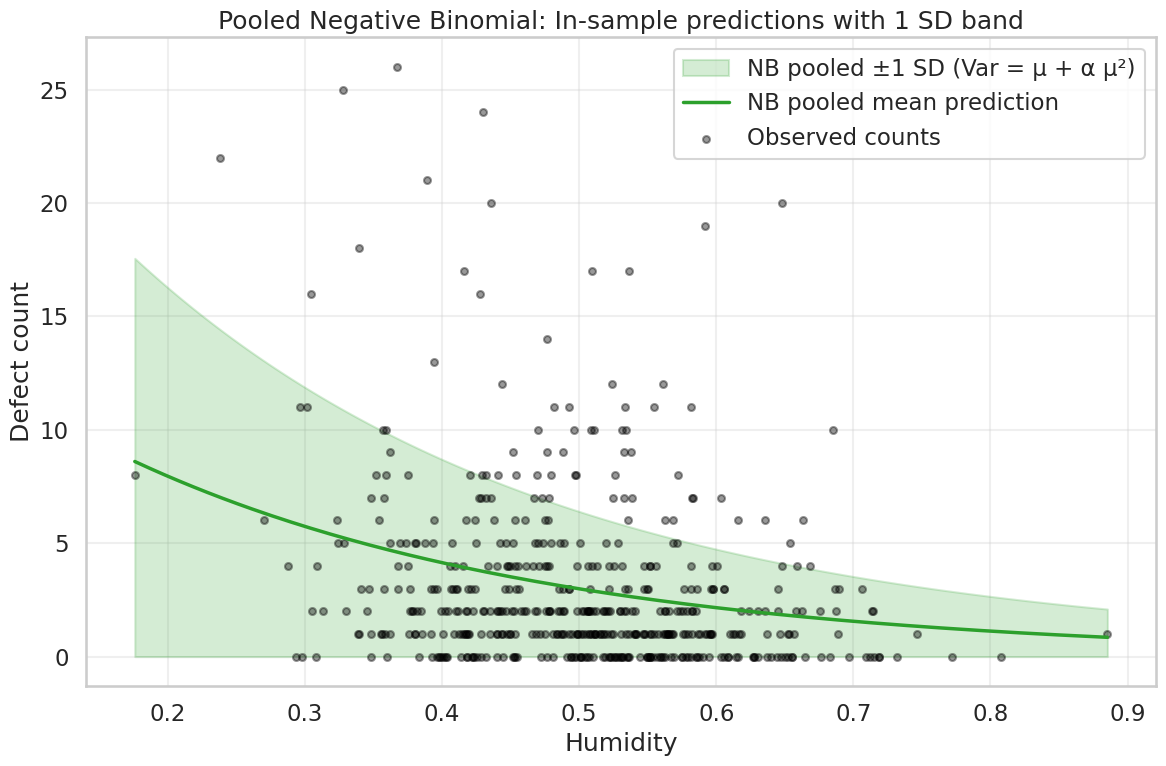

In [17]:
# ============================================================
# 8. Pooled Negative Binomial: In-sample prediction + 1 SD band
# ============================================================

# Fixed-effect parameters from NB pooled model
beta0_nb = float(nb_pooled_result.params[0])
beta1_nb = float(nb_pooled_result.params[1])

# Overdispersion parameter alpha (NB2: Var = μ + α μ^2)
alpha_nb = float(nb_pooled_result.params[-1])

print("\n" + "=" * 60)
print("NEGATIVE BINOMIAL PARAMETERS")
print("=" * 60)
print(f"Intercept (beta0_nb): {beta0_nb:.6f}")
print(f"Humidity  (beta1_nb): {beta1_nb:.6f}")
print(f"exp(beta0_nb): {np.exp(beta0_nb):.6f}")
print(f"exp(beta1_nb): {np.exp(beta1_nb):.6f}")
print(f"Overdispersion alpha: {alpha_nb:.6f}")

# ------------------------------------------------------------
# In-sample mean and SD using NB variance
# ------------------------------------------------------------
h_in = df["humidity"].values

mu_in = np.exp(beta0_nb + beta1_nb * h_in)
var_in = mu_in + alpha_nb * (mu_in ** 2)
sd_in = np.sqrt(var_in)

lower_in = np.clip(mu_in - sd_in, 0, None)
upper_in = mu_in + sd_in

df["mu_nb"] = mu_in
df["mu_nb_lower"] = lower_in
df["mu_nb_upper"] = upper_in

# ------------------------------------------------------------
# Smooth curve over humidity grid
# ------------------------------------------------------------
h_grid = np.linspace(df["humidity"].min(), df["humidity"].max(), 200)

mu_grid = np.exp(beta0_nb + beta1_nb * h_grid)
var_grid = mu_grid + alpha_nb * (mu_grid ** 2)
sd_grid = np.sqrt(var_grid)

lower_grid = np.clip(mu_grid - sd_grid, 0, None)
upper_grid = mu_grid + sd_grid

# ------------------------------------------------------------
# Plot: mean curve + 1 SD band + observed data
# ------------------------------------------------------------
plt.figure(figsize=(12, 8))

plt.fill_between(
    h_grid,
    lower_grid,
    upper_grid,
    color="tab:green",
    alpha=0.2,
    label="NB pooled ±1 SD (Var = μ + α μ²)",
)

plt.plot(
    h_grid,
    mu_grid,
    color="tab:green",
    linewidth=2.5,
    label="NB pooled mean prediction",
)

plt.scatter(
    df["humidity"],
    df["defect_count"],
    s=25,
    alpha=0.4,
    color="black",
    label="Observed counts",
)

plt.xlabel("Humidity")
plt.ylabel("Defect count")
plt.title("Pooled Negative Binomial: In-sample predictions with 1 SD band")
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Result and Interpretation**

A better NB fit does not necessarily mean the estimated humidity effect changes dramatically.  
Often the main difference is that the variability around the mean is represented more realistically.

That matters because uncertainty is part of the model, not an afterthought.  
A model that gets the mean roughly right but badly underestimates the variance can still lead to misleading conclusions in practice.

**Code**


NEGATIVE BINOMIAL RESIDUAL SUMMARY
Mean Pearson residual (NB): -0.000
Std  Pearson residual (NB): 1.096
Approx. dispersion (mean residual^2, NB): 1.198


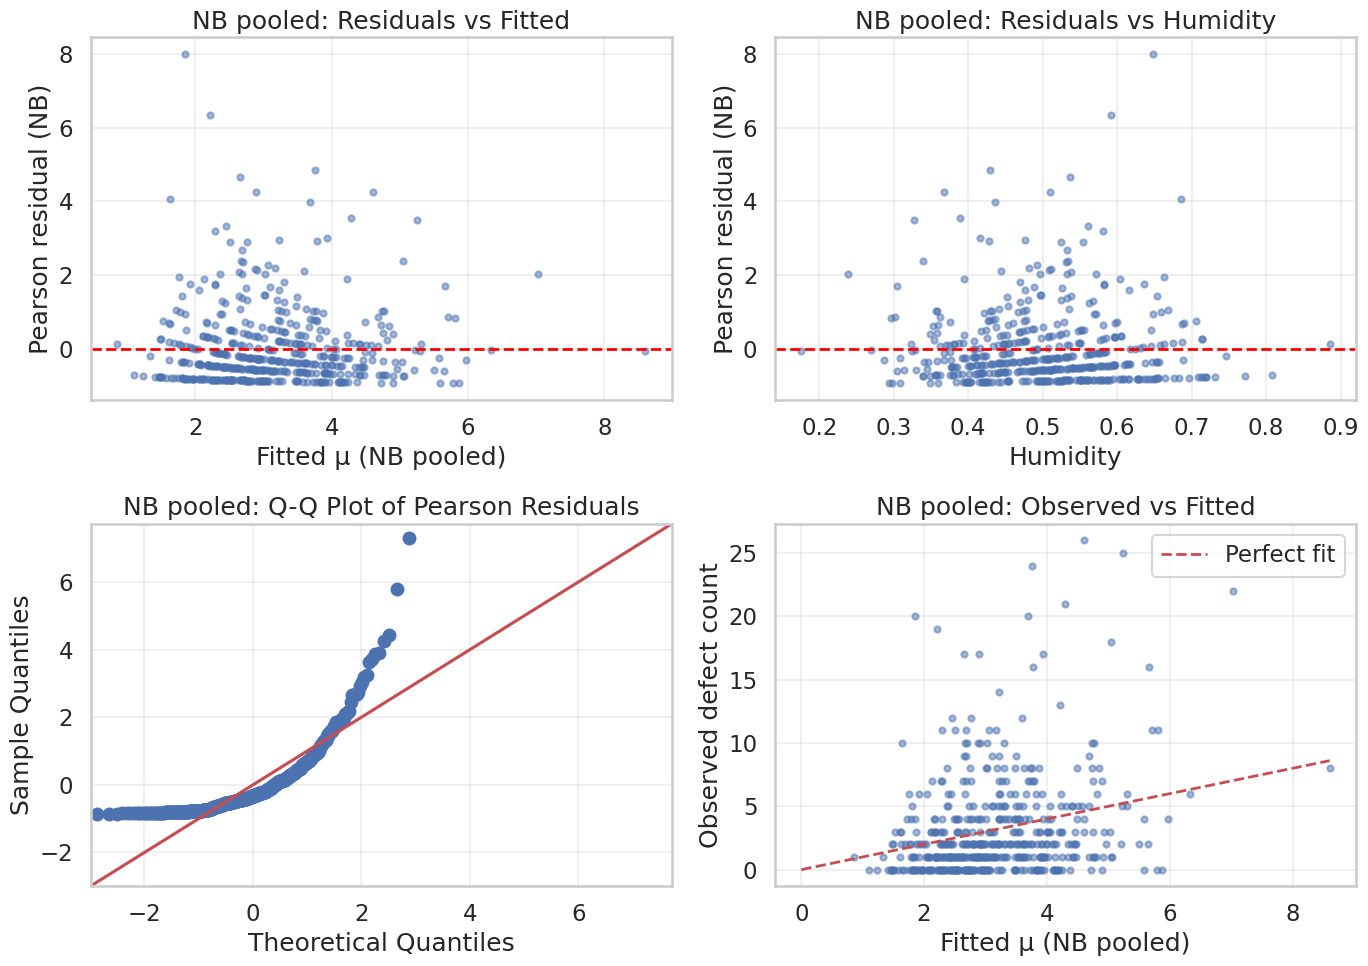


NB POOLED: RESIDUALS BY LOT
      mean    std  count
lot                     
0    0.733  1.339     50
1    1.626  1.836     50
2   -0.585  0.322     50
3   -0.160  0.602     50
4   -0.441  0.458     50
5   -0.165  0.679     50
6   -0.213  0.701     50
7   -0.469  0.459     50
8   -0.107  0.726     50
9   -0.219  0.721     50


<Figure size 1200x500 with 0 Axes>

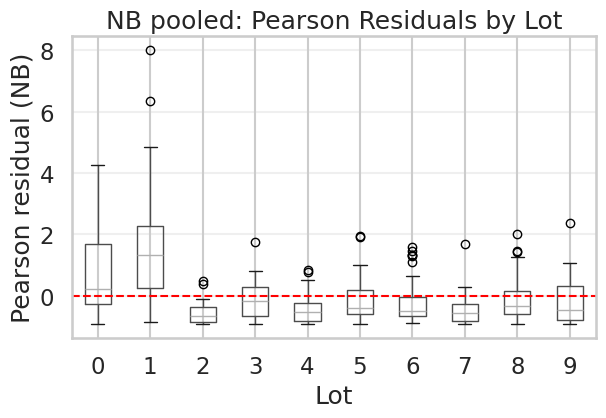


END OF NEGATIVE BINOMIAL RESIDUAL ANALYSIS


In [18]:
# ============================================================
# 9. Residual Diagnostics for Pooled Negative Binomial
# ============================================================

# In-sample mean and variance for NB pooled model
h_in = df["humidity"].values

mu_nb_in = np.exp(beta0_nb + beta1_nb * h_in)
var_nb_in = mu_nb_in + alpha_nb * (mu_nb_in ** 2)

# Pearson residuals for NB
y = df["defect_count"].values
pearson_resid_nb = (y - mu_nb_in) / np.sqrt(var_nb_in)
df["pearson_resid_nb"] = pearson_resid_nb

# ------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("NEGATIVE BINOMIAL RESIDUAL SUMMARY")
print("=" * 60)

print(f"Mean Pearson residual (NB): {df['pearson_resid_nb'].mean():.3f}")
print(f"Std  Pearson residual (NB): {df['pearson_resid_nb'].std(ddof=1):.3f}")

dispersion_nb = np.mean(df["pearson_resid_nb"]**2)
print(f"Approx. dispersion (mean residual^2, NB): {dispersion_nb:.3f}")

# ------------------------------------------------------------
# 4-panel residual plots
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs fitted (NB)
axes[0, 0].scatter(mu_nb_in, df["pearson_resid_nb"], alpha=0.5, s=20)
axes[0, 0].axhline(0, color="red", linestyle="--", linewidth=2)
axes[0, 0].set_xlabel("Fitted μ (NB pooled)")
axes[0, 0].set_ylabel("Pearson residual (NB)")
axes[0, 0].set_title("NB pooled: Residuals vs Fitted")
axes[0, 0].grid(alpha=0.3)

# 2. Residuals vs humidity (NB)
axes[0, 1].scatter(df["humidity"], df["pearson_resid_nb"], alpha=0.5, s=20)
axes[0, 1].axhline(0, color="red", linestyle="--", linewidth=2)
axes[0, 1].set_xlabel("Humidity")
axes[0, 1].set_ylabel("Pearson residual (NB)")
axes[0, 1].set_title("NB pooled: Residuals vs Humidity")
axes[0, 1].grid(alpha=0.3)

# 3. Q-Q plot of Pearson residuals (NB)
sm.qqplot(df["pearson_resid_nb"], line="45", ax=axes[1, 0], fit=True)
axes[1, 0].set_title("NB pooled: Q-Q Plot of Pearson Residuals")
axes[1, 0].grid(alpha=0.3)

# 4. Observed vs fitted counts (NB)
axes[1, 1].scatter(mu_nb_in, df["defect_count"], alpha=0.5, s=20)
max_mu_nb = mu_nb_in.max()
axes[1, 1].plot([0, max_mu_nb], [0, max_mu_nb], "r--", linewidth=2, label="Perfect fit")
axes[1, 1].set_xlabel("Fitted μ (NB pooled)")
axes[1, 1].set_ylabel("Observed defect count")
axes[1, 1].set_title("NB pooled: Observed vs Fitted")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Residuals by lot (NB)
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("NB POOLED: RESIDUALS BY LOT")
print("=" * 60)

lot_resid_nb = (
    df.groupby("lot")["pearson_resid_nb"]
      .agg(["mean", "std", "count"])
      .round(3)
)
print(lot_resid_nb)

plt.figure(figsize=(12, 5))
df.boxplot(column="pearson_resid_nb", by="lot")
plt.suptitle("")
plt.title("NB pooled: Pearson Residuals by Lot")
plt.xlabel("Lot")
plt.ylabel("Pearson residual (NB)")
plt.axhline(0, color="red", linestyle="--", linewidth=1.5)
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("END OF NEGATIVE BINOMIAL RESIDUAL ANALYSIS")
print("=" * 60)

**Result and Interpreation**

## Negative-Binomial GLMM with PyMC

### Introduction
This section extends the earlier count models by allowing both **overdispersion** and between-lot heterogeneity. A negative-binomial generalized linear mixed model (NB GLMM) is appropriate when the defect counts show more variability than a Poisson model can explain and when wafers from the same lot may behave similarly.

The model is implemented in PyMC, which makes the hierarchical structure explicit and allows uncertainty to be propagated through posterior inference. In practical terms, this model estimates an overall humidity effect while also letting each lot have its own intercept and slope adjustments.

**Code**

This code block prepares the hierarchical Bayesian model in PyMC. It first extracts the response, the humidity covariate, and the categorical lot index, then defines coordinates so the posterior output is easier to inspect and interpret.

The fixed effects are represented by `beta0` and `beta1`, which capture the population-level intercept and humidity slope. The random effects are built through latent standard-normal variables `b0raw` and `b1raw`, scaled by `sigmab0` and `sigmab1`, so each lot receives its own deviation in baseline defect level and humidity sensitivity.

The parameter `alpha` controls the negative-binomial overdispersion. This is the key extension beyond a Poisson GLMM, because it allows the conditional variance to exceed the conditional mean, which is often necessary for defect-count data.

The linear predictor combines the population-level and lot-level terms,  
$\eta_i = \beta_0 + \beta_1 h_i + b_{0,\text{lot}(i)} + b_{1,\text{lot}(i)} h_i$,

and the expected count is linked through  
$\mu_i = \exp(\eta_i)$.

The observed counts are then modeled with a negative-binomial likelihood using `mu` and `alpha`, and NUTS sampling is used to draw from the posterior.

In [19]:
# ============================================================
# 10. Negative Binomial GLMM with Lot Random Effects (PyMC v4+)
#    – fixed naming (no dim/data name collision)
# ============================================================

import pymc as pm
import arviz as az

# ---------------------------------------------
# Data preparation
# ---------------------------------------------
y = df["defect_count"].values
h = df["humidity"].values

lots_cat = df["lot"].astype("category")
lot_idx = lots_cat.cat.codes.values  # 0 .. n_lots-1
n_lots = lots_cat.cat.categories.size

coords = {
    "obs": np.arange(df.shape[0]),
    "lot": lots_cat.cat.categories,
}

with pm.Model(coords=coords) as nb_glmm_model:
    # Data containers (names differ from dim labels)
    humidity_data = pm.Data("humidity_data", h, dims="obs")
    lot_index = pm.Data("lot_index", lot_idx, dims="obs")

    # -------------------------
    # Fixed effects
    # -------------------------
    beta0 = pm.Normal("beta0", mu=0.0, sigma=5.0)
    beta1 = pm.Normal("beta1", mu=0.0, sigma=5.0)

    # -------------------------
    # Random effects per lot
    #   b0_j ~ N(0, sigma_b0^2)
    #   b1_j ~ N(0, sigma_b1^2)
    # -------------------------
    sigma_b0 = pm.HalfNormal("sigma_b0", sigma=1.0)
    sigma_b1 = pm.HalfNormal("sigma_b1", sigma=1.0)

    b0_raw = pm.Normal("b0_raw", mu=0.0, sigma=1.0, dims="lot")
    b1_raw = pm.Normal("b1_raw", mu=0.0, sigma=1.0, dims="lot")

    b0 = pm.Deterministic("b0", sigma_b0 * b0_raw, dims="lot")
    b1 = pm.Deterministic("b1", sigma_b1 * b1_raw, dims="lot")

    # Overdispersion parameter alpha (NB2, Var = μ + α μ²)
    alpha = pm.HalfNormal("alpha", sigma=1.0)

    # -------------------------
    # Linear predictor and mean
    # -------------------------
    b0_lot = b0[lot_index]
    b1_lot = b1[lot_index]

    eta = beta0 + beta1 * humidity_data + b0_lot + b1_lot * humidity_data
    mu = pm.Deterministic("mu", pm.math.exp(eta), dims="obs")

    # -------------------------
    # Likelihood
    # -------------------------
    y_obs = pm.NegativeBinomial(
        "y_obs",
        mu=mu,
        alpha=alpha,
        observed=y,
        dims="obs",
    )

    # -------------------------
    # Sampling
    # -------------------------
    nb_glmm_trace = pm.sample(
        draws=1000,
        tune=1000,
        target_accept=0.9,
        chains=4,
        cores=4,
        return_inferencedata=True,
    )

    nb_glmm_ppc = pm.sample_posterior_predictive(
        nb_glmm_trace,
        var_names=["y_obs", "mu"],
    )

# ============================================================
# NB GLMM (PyMC) – Extract mu and prepare for visualization
# ============================================================

import xarray as xr

# Posterior samples of mu: dims (chain, draw, obs)
mu_posterior = nb_glmm_trace.posterior["mu"]  # xarray DataArray

# Collapse chains and draws
mu_post_stacked = mu_posterior.stack(sample=("chain", "draw"))  # (sample, obs)

mu_mean = mu_post_stacked.mean(dim="sample").values
mu_sd = mu_post_stacked.std(dim="sample").values

df["mu_nb_glmm_mean"] = mu_mean
df["mu_nb_glmm_sd"] = mu_sd
df["mu_nb_glmm_lower"] = np.clip(mu_mean - mu_sd, 0, None)
df["mu_nb_glmm_upper"] = mu_mean + mu_sd

print("\nPrepared df columns for plotting:")
print("  mu_nb_glmm_mean, mu_nb_glmm_lower, mu_nb_glmm_upper")



Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta0, beta1, sigma_b0, sigma_b1, b0_raw, b1_raw, alpha]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 37 seconds.
Sampling: [y_obs]


Output()


Prepared df columns for plotting:
  mu_nb_glmm_mean, mu_nb_glmm_lower, mu_nb_glmm_upper


**Result and Interpretation**

The posterior summary indicates a positive intercept and a clearly negative humidity coefficient. This means the expected defect count decreases as humidity increases, and the posterior mean of the exponentiated slope suggests a substantial multiplicative reduction in expected defects for a one-unit increase in humidity.

The lot-level standard deviations `sigmab0` and `sigmab1` are both nonzero, which supports the presence of meaningful between-lot variability in both the baseline count level and the humidity effect. In other words, lots do not all start from the same defect rate, and they do not all respond to humidity in exactly the same way.

The estimated overdispersion parameter `alpha` is also clearly positive and fairly large, which confirms that a plain Poisson specification would be too restrictive for these data. This is strong evidence that the NB GLMM is better aligned with the observed variability than a Poisson GLMM with the same random-effects structure.

The MCMC diagnostics are reassuring: effective sample sizes are high and $\hat{R}$ values are essentially 1.00. That indicates the chains mixed well and that the posterior summaries are stable enough to support interpretation.

**Code:** Extract coefficients

This code block extracts posterior samples of the fitted mean `mu` from the PyMC trace and reshapes them into a convenient format for summary and plotting. By stacking the chain and draw dimensions into a single sample dimension, it becomes easy to compute the posterior mean and posterior standard deviation for each observation.

The resulting columns `munbglmmmean`, `munbglmmlower`, and `munbglmmupper` provide observation-level fitted values and simple uncertainty bands. These quantities are useful for fitted-versus-observed plots, residual diagnostics, and comparisons with the pooled negative-binomial model.

In [20]:
# ============================================================
# 11. NB GLMM (PyMC) – Coefficients, predictions, residuals
#     Population-level (new-lot) view
# ============================================================

import xarray as xr

# -------------------------
# 1. Coefficient summaries
# -------------------------

summary_nb_glmm = az.summary(
    nb_glmm_trace,
    var_names=["beta0", "beta1", "sigma_b0", "sigma_b1", "alpha"],
)
print("\n" + "=" * 60)
print("NEGATIVE BINOMIAL GLMM (PyMC) – PARAMETER SUMMARY")
print("=" * 60)
print(summary_nb_glmm)

beta0_mean = float(summary_nb_glmm.loc["beta0", "mean"])
beta1_mean = float(summary_nb_glmm.loc["beta1", "mean"])
alpha_mean = float(summary_nb_glmm.loc["alpha", "mean"])

print("\nFixed effects (population-level):")
print(f"  beta0 (Intercept): {beta0_mean:.6f}  (exp = {np.exp(beta0_mean):.6f})")
print(f"  beta1 (Humidity):  {beta1_mean:.6f}  (exp = {np.exp(beta1_mean):.6f})")
print(f"  Overdispersion α:  {alpha_mean:.6f}")


NEGATIVE BINOMIAL GLMM (PyMC) – PARAMETER SUMMARY
           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta0     2.508  0.293   1.973    3.061      0.005    0.005    2997.0   
beta1    -3.219  0.521  -4.219   -2.280      0.008    0.009    4152.0   
sigma_b0  0.553  0.242   0.005    0.936      0.008    0.005     855.0   
sigma_b1  0.646  0.411   0.002    1.328      0.013    0.006    1032.0   
alpha     1.934  0.216   1.547    2.352      0.002    0.004    7682.0   

          ess_tail  r_hat  
beta0       2880.0    1.0  
beta1       2756.0    1.0  
sigma_b0     645.0    1.0  
sigma_b1    2067.0    1.0  
alpha       2879.0    1.0  

Fixed effects (population-level):
  beta0 (Intercept): 2.508000  (exp = 12.280345)
  beta1 (Humidity):  -3.219000  (exp = 0.039995)
  Overdispersion α:  1.934000


**Result and Interpretation**

The extracted posterior means represent the model's expected defect counts after combining fixed effects, lot-specific random effects, and the negative-binomial structure. Because they are posterior summaries, they are more informative than a single point estimate from a classical fit: they show both the central prediction and the uncertainty around it.

If the uncertainty bands are relatively narrow for some observations and wider for others, that pattern reflects how confidently the model can predict each wafer's count. Wider intervals typically occur where the data are noisier or where the lot-specific effects are less precisely learned.

**Code**

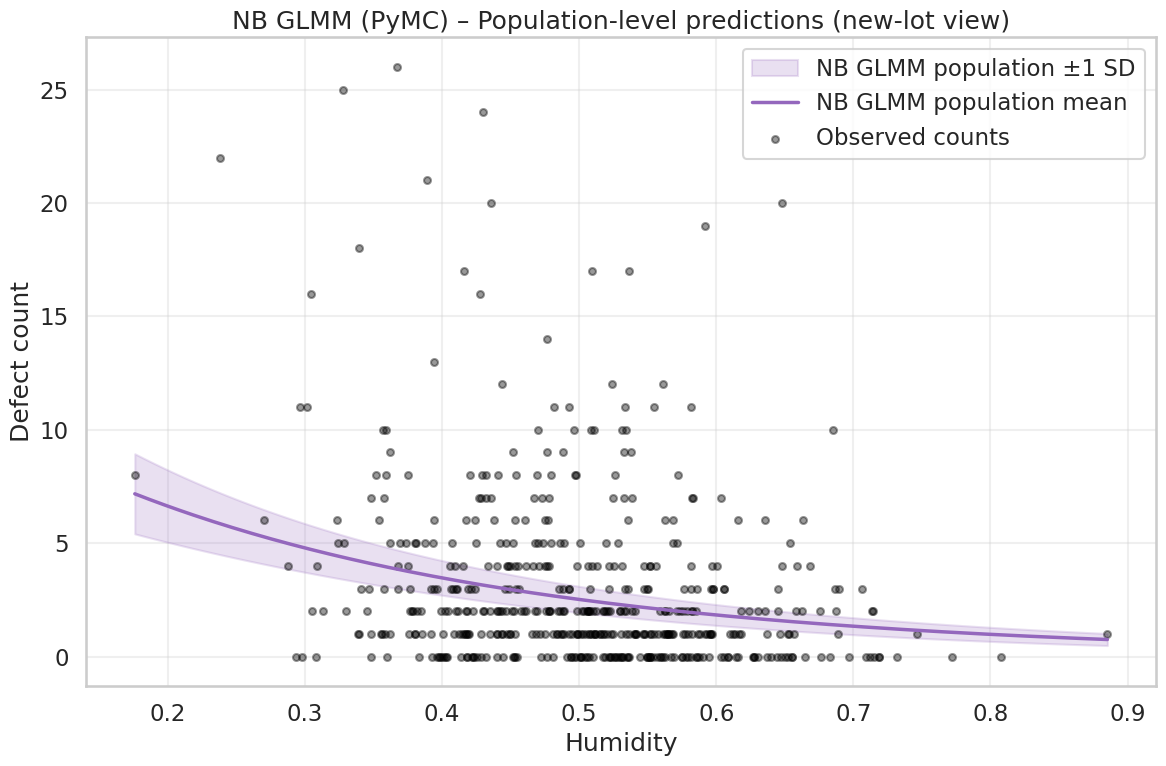

In [21]:
# -------------------------
# 2. Population-level predictions
# -------------------------

# Posterior draws for beta0, beta1, alpha
beta0_post = nb_glmm_trace.posterior["beta0"]
beta1_post = nb_glmm_trace.posterior["beta1"]
alpha_post = nb_glmm_trace.posterior["alpha"]

beta0_stack = beta0_post.stack(sample=("chain", "draw"))
beta1_stack = beta1_post.stack(sample=("chain", "draw"))
alpha_stack = alpha_post.stack(sample=("chain", "draw"))
n_sample = beta0_stack.sizes["sample"]

# In-sample predictions (population-level, no random effects)
h_in = df["humidity"].values
y_in = df["defect_count"].values

h_mat_in = np.broadcast_to(h_in, (n_sample, h_in.shape[0]))

eta_pop_in = beta0_stack.values[:, None] + beta1_stack.values[:, None] * h_mat_in
mu_pop_in = np.exp(eta_pop_in)
alpha_vals = alpha_stack.values[:, None]

var_pop_in = mu_pop_in + alpha_vals * (mu_pop_in ** 2)
sd_pop_in = np.sqrt(var_pop_in)

mu_pop_in_mean = mu_pop_in.mean(axis=0)
mu_pop_in_sd = mu_pop_in.std(axis=0)

df["mu_nb_glmm_pop_mean"] = mu_pop_in_mean
df["mu_nb_glmm_pop_sd"] = mu_pop_in_sd
df["mu_nb_glmm_pop_lower"] = np.clip(mu_pop_in_mean - mu_pop_in_sd, 0, None)
df["mu_nb_glmm_pop_upper"] = mu_pop_in_mean + mu_pop_in_sd

# Smooth curve over humidity grid
h_grid = np.linspace(df["humidity"].min(), df["humidity"].max(), 200)
h_mat_grid = np.broadcast_to(h_grid, (n_sample, h_grid.shape[0]))

eta_pop_grid = beta0_stack.values[:, None] + beta1_stack.values[:, None] * h_mat_grid
mu_pop_grid = np.exp(eta_pop_grid)
var_pop_grid = mu_pop_grid + alpha_vals[:, :mu_pop_grid.shape[1]] * (mu_pop_grid ** 2)
sd_pop_grid = np.sqrt(var_pop_grid)

mu_grid_mean = mu_pop_grid.mean(axis=0)
mu_grid_sd = mu_pop_grid.std(axis=0)
mu_grid_lower = np.clip(mu_grid_mean - mu_grid_sd, 0, None)
mu_grid_upper = mu_grid_mean + mu_grid_sd

# Plot: smooth curve + band + scatter
plt.figure(figsize=(12, 8))

plt.fill_between(
    h_grid,
    mu_grid_lower,
    mu_grid_upper,
    color="tab:purple",
    alpha=0.2,
    label="NB GLMM population ±1 SD",
)

plt.plot(
    h_grid,
    mu_grid_mean,
    color="tab:purple",
    linewidth=2.5,
    label="NB GLMM population mean",
)

plt.scatter(
    df["humidity"],
    df["defect_count"],
    s=25,
    alpha=0.4,
    color="black",
    label="Observed counts",
)

plt.xlabel("Humidity")
plt.ylabel("Defect count")
plt.title("NB GLMM (PyMC) – Population-level predictions (new-lot view)")
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Result and Interpretation**

**Code**


NB GLMM (population-level) – RESIDUAL SUMMARY
Mean Pearson residual: 0.118
Std  Pearson residual: 0.952
Approx. dispersion (mean residual^2): 0.919


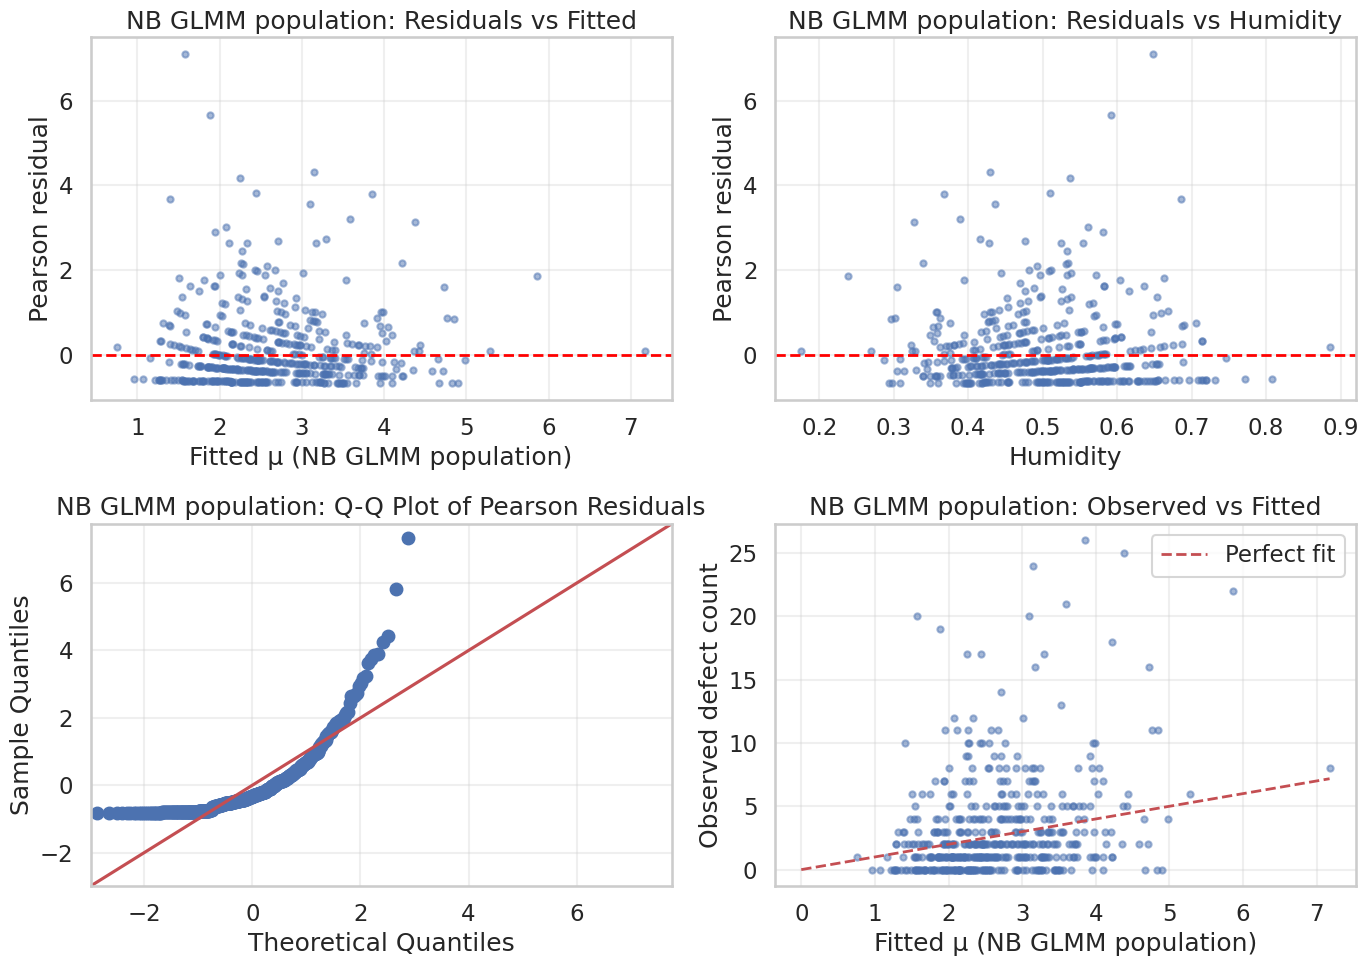


NB GLMM (population-level): RESIDUALS BY LOT
      mean    std  count
lot                     
0    0.755  1.161     50
1    1.531  1.597     50
2   -0.389  0.280     50
3   -0.021  0.522     50
4   -0.266  0.397     50
5   -0.025  0.590     50
6   -0.066  0.609     50
7   -0.291  0.399     50
8    0.026  0.630     50
9   -0.072  0.626     50


<Figure size 1200x500 with 0 Axes>

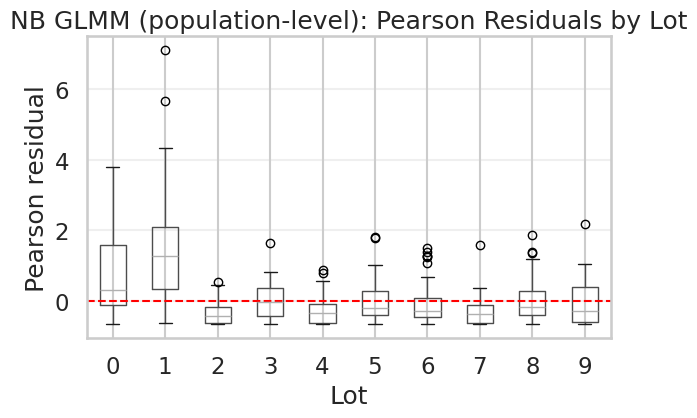

In [22]:
# -------------------------
# 3. Residuals and diagnostics
# -------------------------

# Pearson residuals using posterior mean mu and variance at each point
var_pop_in_mean = var_pop_in.mean(axis=0)
pearson_resid_nb_glmm_pop = (y_in - mu_pop_in_mean) / np.sqrt(var_pop_in_mean)
df["pearson_resid_nb_glmm_pop"] = pearson_resid_nb_glmm_pop

disp_nb_glmm_pop = np.mean(df["pearson_resid_nb_glmm_pop"]**2)

print("\n" + "=" * 60)
print("NB GLMM (population-level) – RESIDUAL SUMMARY")
print("=" * 60)
print(f"Mean Pearson residual: {df['pearson_resid_nb_glmm_pop'].mean():.3f}")
print(f"Std  Pearson residual: {df['pearson_resid_nb_glmm_pop'].std(ddof=1):.3f}")
print(f"Approx. dispersion (mean residual^2): {disp_nb_glmm_pop:.3f}")

# 4-panel residual plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs fitted
axes[0, 0].scatter(
    df["mu_nb_glmm_pop_mean"],
    df["pearson_resid_nb_glmm_pop"],
    alpha=0.5, s=20
)
axes[0, 0].axhline(0, color="red", linestyle="--", linewidth=2)
axes[0, 0].set_xlabel("Fitted μ (NB GLMM population)")
axes[0, 0].set_ylabel("Pearson residual")
axes[0, 0].set_title("NB GLMM population: Residuals vs Fitted")
axes[0, 0].grid(alpha=0.3)

# 2. Residuals vs humidity
axes[0, 1].scatter(
    df["humidity"],
    df["pearson_resid_nb_glmm_pop"],
    alpha=0.5, s=20
)
axes[0, 1].axhline(0, color="red", linestyle="--", linewidth=2)
axes[0, 1].set_xlabel("Humidity")
axes[0, 1].set_ylabel("Pearson residual")
axes[0, 1].set_title("NB GLMM population: Residuals vs Humidity")
axes[0, 1].grid(alpha=0.3)

# 3. Q-Q plot of Pearson residuals
sm.qqplot(df["pearson_resid_nb_glmm_pop"], line="45", ax=axes[1, 0], fit=True)
axes[1, 0].set_title("NB GLMM population: Q-Q Plot of Pearson Residuals")
axes[1, 0].grid(alpha=0.3)

# 4. Observed vs fitted
axes[1, 1].scatter(
    df["mu_nb_glmm_pop_mean"],
    df["defect_count"],
    alpha=0.5, s=20
)
max_mu = df["mu_nb_glmm_pop_mean"].max()
axes[1, 1].plot([0, max_mu], [0, max_mu], "r--", linewidth=2, label="Perfect fit")
axes[1, 1].set_xlabel("Fitted μ (NB GLMM population)")
axes[1, 1].set_ylabel("Observed defect count")
axes[1, 1].set_title("NB GLMM population: Observed vs Fitted")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# NB GLMM (population-level): Pearson residuals by lot
# ============================================================

print("\n" + "=" * 60)
print("NB GLMM (population-level): RESIDUALS BY LOT")
print("=" * 60)

lot_resid_nb_glmm = (
    df.groupby("lot")["pearson_resid_nb_glmm_pop"]
      .agg(["mean", "std", "count"])
      .round(3)
)
print(lot_resid_nb_glmm)

plt.figure(figsize=(12, 5))
df.boxplot(column="pearson_resid_nb_glmm_pop", by="lot")
plt.suptitle("")
plt.title("NB GLMM (population-level): Pearson Residuals by Lot")
plt.xlabel("Lot")
plt.ylabel("Pearson residual")
plt.axhline(0, color="red", linestyle="--", linewidth=1.5)
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

**Result and Interpretation**

This NB GLMM should be viewed as the most flexible count model in the notebook among the main candidates. It accounts for three important features at once: a nonlinear mean-variance relationship, repeated observations within lots, and uncertainty in lot-specific behavior.

That makes it especially valuable when the goal is not only to estimate an average humidity effect, but also to make realistic predictions for wafers coming from heterogeneous production lots. In applications, this is often the model that best balances interpretability and predictive realism.

## 7. Comparing models and predictions

At this point the notebook contains three main perspectives on the same count process: a pooled Poisson model, a Poisson mixed model, and a Negative Binomial model.  
The goal of this section is to compare them in terms of fit, interpretation, and predictive behavior.

**Code: Compare model predictions across humidity values**

The next code cell evaluates how the competing models map humidity into predicted defect counts.  
This makes it easier to see whether the models agree on the mean trend and where they start to differ.

In [23]:
# ============================================================
# 12. Model Comparison Table – Poisson & NB (pooled vs GLMM)
#     Using residual-based dispersion and classical metrics
# ============================================================

metrics = []

def dispersion_from_resid(resid_series):
    return float(np.mean(resid_series**2))

# 1. Pooled Poisson GLM
metrics.append({
    "model": "pooled_poisson",
    "type": "Poisson GLM (no lot)",
    "aic": float(pooled_poisson.aic),
    "bic": float(pooled_poisson.bic),
    "loglik": float(pooled_poisson.llf),
    "pearson_dispersion": dispersion_from_resid(df["pearson_resid"]),
})

# 2. Poisson GLMM (statsmodels)
# PoissonBayesMixedGLM doesn't give standard AIC/BIC; logposterior is not directly comparable.
# We focus on dispersion here.
metrics.append({
    "model": "poisson_glmm",
    "type": "Poisson GLMM (lot RE)",
    "aic": np.nan,
    "bic": np.nan,
    "loglik": np.nan,
    "pearson_dispersion": dispersion_from_resid(df["pearson_resid_glmm"]),
})

# 3. Pooled Negative Binomial
metrics.append({
    "model": "neg_bin_pooled",
    "type": "NB pooled (NB2)",
    "aic": float(nb_pooled_result.aic),
    "bic": float(nb_pooled_result.bic),
    "loglik": float(nb_pooled_result.llf),
    "pearson_dispersion": dispersion_from_resid(df["pearson_resid_nb"]),
})

# 4. NB GLMM (PyMC) – population-level residuals
metrics.append({
    "model": "neg_bin_glmm",
    "type": "NB GLMM (lot RE, PyMC, population view)",
    "aic": np.nan,   # not defined in this Bayesian fit
    "bic": np.nan,
    "loglik": np.nan,
    "pearson_dispersion": dispersion_from_resid(df["pearson_resid_nb_glmm_pop"]),
})

metrics_df = pd.DataFrame(metrics)
metrics_df = metrics_df[["model", "type", "aic", "bic", "loglik", "pearson_dispersion"]]

print("\n" + "=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)
print(metrics_df.round(3))


MODEL COMPARISON SUMMARY
            model                                     type       aic  \
0  pooled_poisson                     Poisson GLM (no lot)  3004.162   
1    poisson_glmm                    Poisson GLMM (lot RE)       NaN   
2  neg_bin_pooled                          NB pooled (NB2)  2255.763   
3    neg_bin_glmm  NB GLMM (lot RE, PyMC, population view)       NaN   

        bic    loglik  pearson_dispersion  
0 -1227.917 -1500.081               4.669  
1       NaN       NaN               2.422  
2  2268.407 -1124.882               1.198  
3       NaN       NaN               0.919  


/home/python_user/coding/ds/.venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


**Result and Interpretation**

If the models agree closely on the mean trend, then the main modeling disagreement is about variability rather than the sign of the humidity effect.  
If they differ materially in the fitted mean itself, then the choice of model also changes the substantive process interpretation.

This is why model comparison should not rely on a single fit statistic alone.  
Two models may tell a similar story about the mean but a very different story about uncertainty and residual structure.

## 7. Comparing models with partial lot data (BLUP)

In many practical situations we see a few wafers from a lot and want to decide early whether that lot is at risk. Here, the random‑intercept model has an advantage: it can use the observed wafers to compute a **BLUP** for the lot’s random intercept and adjust predictions for the remaining wafers accordingly, whereas the pooled model cannot.

**Code: simulate partial observations per lot and compute BLUP‑based predictions**



In [24]:
# ============================================================
# B. New in-lot test predictions + metrics for all models
# ============================================================

from sklearn.metrics import mean_squared_error, mean_absolute_error

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

def pearson_dispersion_counts(y_true, y_pred):
    lam = np.clip(y_pred, 1e-8, None)
    resid = (y_true - lam) / np.sqrt(lam)
    return float(np.mean(resid**2))

y_test = df_test_new["defect_count"].values
h_test = df_test_new["humidity"].values

metrics_test = []

# -----------------------------
# 1. Pooled Poisson GLM
# -----------------------------
X_test_poiss = sm.add_constant(df_test_new[["humidity"]])
lambda_pooled_test = pooled_poisson.predict(X_test_poiss)

metrics_test.append({
    "model": "pooled_poisson",
    "type": "Poisson GLM (no lot)",
    "rmse": rmse(y_test, lambda_pooled_test),
    "mae": mae(y_test, lambda_pooled_test),
    "pearson_dispersion": pearson_dispersion_counts(y_test, lambda_pooled_test),
})

# -----------------------------
# 2. Poisson GLMM (existing-lot prediction)
# -----------------------------
lots_test = pd.Categorical(df_test_new["lot"], categories=lot_levels)
X_fe_test = sm.add_constant(df_test_new[["humidity"]]).values

Z_list_test = []
for lot in lot_levels:
    mask = (lots_test == lot)
    Zi = np.zeros((df_test_new.shape[0], 2))
    Zi[mask, 0] = 1.0
    Zi[mask, 1] = df_test_new.loc[mask, "humidity"].values
    Z_list_test.append(Zi)
X_re_test = np.concatenate(Z_list_test, axis=1)

linpred_glmm_test = (
    X_fe_test @ poisson_glmm_result.fe_mean
    + X_re_test @ poisson_glmm_result.vc_mean
)
lambda_glmm_test = np.exp(linpred_glmm_test)

metrics_test.append({
    "model": "poisson_glmm",
    "type": "Poisson GLMM (lot RE)",
    "rmse": rmse(y_test, lambda_glmm_test),
    "mae": mae(y_test, lambda_glmm_test),
    "pearson_dispersion": pearson_dispersion_counts(y_test, lambda_glmm_test),
})

# -----------------------------
# 3. Pooled Negative Binomial
# -----------------------------
X_test_nb = sm.add_constant(df_test_new[["humidity"]]).values
mu_nb_pooled_test = nb_pooled_result.predict(X_test_nb)

metrics_test.append({
    "model": "neg_bin_pooled",
    "type": "NB pooled (NB2)",
    "rmse": rmse(y_test, mu_nb_pooled_test),
    "mae": mae(y_test, mu_nb_pooled_test),
    "pearson_dispersion": pearson_dispersion_counts(y_test, mu_nb_pooled_test),
})

# -----------------------------
# 4. NB GLMM (PyMC) – existing-lot prediction using posterior means
# -----------------------------
# Posterior means for fixed effects
beta0_mean = float(nb_glmm_trace.posterior["beta0"].mean())
beta1_mean = float(nb_glmm_trace.posterior["beta1"].mean())

# Posterior means for random effects per lot
b0_mean = nb_glmm_trace.posterior["b0"].mean(dim=("chain", "draw")).values  # (n_lots,)
b1_mean = nb_glmm_trace.posterior["b1"].mean(dim=("chain", "draw")).values

lot_idx_test = lots_test.codes
b0_test = b0_mean[lot_idx_test]
b1_test = b1_mean[lot_idx_test]

eta_nb_glmm_test = (
    beta0_mean
    + beta1_mean * h_test
    + b0_test
    + b1_test * h_test
)
mu_nb_glmm_test = np.exp(eta_nb_glmm_test)

metrics_test.append({
    "model": "neg_bin_glmm",
    "type": "NB GLMM (lot RE, PyMC)",
    "rmse": rmse(y_test, mu_nb_glmm_test),
    "mae": mae(y_test, mu_nb_glmm_test),
    "pearson_dispersion": pearson_dispersion_counts(y_test, mu_nb_glmm_test),
})

# -----------------------------
# Build and display metrics table
# -----------------------------
metrics_test_df = pd.DataFrame(metrics_test)
metrics_test_df = metrics_test_df[["model", "type", "rmse", "mae", "pearson_dispersion"]]

print("\n" + "=" * 60)
print("NEW IN-LOT TEST SET – MODEL PERFORMANCE")
print("=" * 60)
print(metrics_test_df.round(3))


NEW IN-LOT TEST SET – MODEL PERFORMANCE
            model                    type   rmse    mae  pearson_dispersion
0  pooled_poisson    Poisson GLM (no lot)  3.586  2.502               3.495
1    poisson_glmm   Poisson GLMM (lot RE)  3.179  2.146               2.459
2  neg_bin_pooled         NB pooled (NB2)  3.587  2.500               3.504
3    neg_bin_glmm  NB GLMM (lot RE, PyMC)  3.175  2.146               2.453


**Result and Interpretation**

This should have improved the GLMM BLUP prediction, but training with little data makes the predictions uncertain and thuse they fail.


## 8. Evaluation, theory/code summary, and possible extensions

The notebook illustrates a broader lesson about hierarchical count data.  
Humidity may explain part of the response, but semiconductor measurements often contain both clustering and extra-Poisson variability, so a single pooled Poisson regression is rarely the full story.

From a modeling point of view, the main ideas are:

- The Poisson GLM is a clean baseline for count regression.
- A Poisson mixed model captures latent lot-to-lot heterogeneity.
- A Negative Binomial model captures overdispersion in the count variance.
- Diagnostic plots and variance checks are essential for deciding which structure is missing.

### Final interpretation

The important takeaway is not only whether humidity has an effect, but also how the assumed stochastic structure changes the interpretation of that effect.  
A model that gets the mean approximately right but the variance badly wrong can still produce misleading uncertainty statements and misleading practical conclusions.

That is why the notebook proceeds in stages: first the generative story, then raw summaries and EDA, then a baseline Poisson model, and finally richer models that address the structure visible in the data.  
This makes the analysis easier to understand statistically and easier to justify from a data-science perspective.